# ECG Verification Thesis — HDC + PINN Hybrid Colab (Version 3)

This notebook is the **thesis-oriented version** with a more explicit **physics residual** inside the hybrid model.

## Model lineup

1. **Demo 1:** Classical baseline using handcrafted features + SVM  
2. **Demo 2:** Deep baseline using a lightweight 1D CNN  
3. **Demo 3:** Stronger verification baseline using a Siamese CNN-BiLSTM  
4. **Demo 4:** **HDC baseline** for fast ECG authentication  
5. **Demo 5:** **HDC + PINN hybrid with explicit FitzHugh–Nagumo residual**  
6. **Demo 6:** Timing, robustness, and cross-dataset evaluation

# Added Fixes
The previous notebook used only:
- verification loss
- reconstruction loss
- smoothness penalty
- morphology consistency

This version adds an explicit **physics loss** based on a simplified **FitzHugh–Nagumo (FHN)** residual:

$$
\frac{dv}{dt} = v - \frac{v^3}{3} - w + I
$$

$$
\frac{dw}{dt} = \epsilon (v + a - bw)
$$

and the physics residual loss is approximated as:
$$
L_{\text{phys}}
=
\left\|
\frac{dv}{dt} - \left(v - \frac{v^3}{3} - w + I\right)
\right\|^2
+
\left\|
\frac{dw}{dt} - \epsilon (v + a - bw)
\right\|^2
$$




## What will make this notebook thesis-strong

This notebook is already a strong **thesis prototype**, but the final thesis should clearly answer four questions:

1. **Does the proposed hybrid outperform simpler baselines?**  
   Adding a direct **ablation study**

2. **Is the PINN claim defensible?**  
   Check results

3. **Is the method useful for real authentication?**  
   the **timing**, **short-window**, and **robustness** sections help in that

4. **Is the evaluation academically rigorous?**  
   Futurework




In [ ]:

# 0. Environment setup

!pip -q install wfdb scipy scikit-learn matplotlib pandas numpy tqdm seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 215.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.


In [ ]:
# =========================
# 1. Imports and config
# =========================
import os
import gc
import math
import time
import random
import warnings
from dataclasses import dataclass, asdict
from typing import List, Tuple, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.signal import butter, filtfilt, find_peaks
from scipy.spatial.distance import cosine
from scipy.interpolate import interp1d

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, confusion_matrix
)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import wfdb

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [ ]:
# =========================
# 2. Global configuration
# =========================
@dataclass
class CFG:
    # Dataset controls
    dataset_name: str = "ecg_id"     # "ecg_id" or "ptb"
    data_root: str = "./ecg_data"
    max_subjects: int = 100           # keep small first; raise later
    max_records_per_subject: int = 4
    primary_lead: int = 0

    # Signal preprocessing
    fs_ecg_id: int = 500
    fs_ptb: int = 1000               # many PTB records are 1000 Hz
    target_fs: int = 250
    segment_seconds: float = 2.0
    bandpass_low: float = 0.5
    bandpass_high: float = 40.0
    normalize_per_segment: bool = True

    # Pair generation
    positive_pairs_per_subject: int = 40
    negative_pairs_per_subject: int = 40

    # Training
    batch_size: int = 64
    epochs: int = 8
    lr: float = 1e-3
    weight_decay: float = 1e-4
    embedding_dim: int = 64

    # Robustness tests
    noise_std_list: tuple = (0.00, 0.01, 0.03, 0.05)
    dropped_fraction_list: tuple = (0.00, 0.05, 0.10)

    # Timing
    timing_warmup: int = 20
    timing_trials: int = 100

cfg = CFG()
print(asdict(cfg))

{'dataset_name': 'ecg_id', 'data_root': './ecg_data', 'max_subjects': 100, 'max_records_per_subject': 4, 'primary_lead': 0, 'fs_ecg_id': 500, 'fs_ptb': 1000, 'target_fs': 250, 'segment_seconds': 2.0, 'bandpass_low': 0.5, 'bandpass_high': 40.0, 'normalize_per_segment': True, 'positive_pairs_per_subject': 40, 'negative_pairs_per_subject': 40, 'batch_size': 64, 'epochs': 8, 'lr': 0.001, 'weight_decay': 0.0001, 'embedding_dim': 64, 'noise_std_list': (0.0, 0.01, 0.03, 0.05), 'dropped_fraction_list': (0.0, 0.05, 0.1), 'timing_warmup': 20, 'timing_trials': 100}


## Dataset helpers

This notebook supports two datasets:

- **ECG-ID** for main subject verification experiments
- **PTB Diagnostic** for external validation / cross-dataset tests

Because PhysioNet directory structures can be slightly annoying, the helper code below downloads a subset and builds a clean metadata table.

In [ ]:
# =========================
# 3. Utility functions
# =========================
def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)

def butter_bandpass_filter(x, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, x)

def resample_signal(x, orig_fs, target_fs):
    if orig_fs == target_fs:
        return x
    duration = len(x) / orig_fs
    new_len = int(duration * target_fs)
    return signal.resample(x, new_len)

def zscore(x):
    x = np.asarray(x, dtype=np.float32)
    mu = x.mean()
    sd = x.std() + 1e-8
    return (x - mu) / sd

def segment_signal(x, fs, segment_seconds=2.0, step_seconds=1.0):
    seg_len = int(segment_seconds * fs)
    step = int(step_seconds * fs)
    segments = []
    for start in range(0, len(x) - seg_len + 1, step):
        seg = x[start:start + seg_len].copy()
        segments.append(seg)
    return segments

def add_gaussian_noise(x, std=0.01):
    return x + np.random.normal(0, std, size=len(x))

def drop_samples_and_interpolate(x, drop_fraction=0.05):
    if drop_fraction <= 0:
        return x.copy()
    n = len(x)
    k = int(n * drop_fraction)
    idx = np.arange(n)
    drop_idx = np.random.choice(idx, size=k, replace=False)
    keep_mask = np.ones(n, dtype=bool)
    keep_mask[drop_idx] = False
    if keep_mask.sum() < 2:
        return x.copy()
    f = interp1d(idx[keep_mask], x[keep_mask], kind="linear", fill_value="extrapolate")
    return f(idx).astype(np.float32)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def cosine_similarity_np(a, b):
    return 1.0 - cosine(a, b)

def plot_one_signal(x, fs, title="ECG Segment"):
    t = np.arange(len(x)) / fs
    plt.figure(figsize=(10, 3))
    plt.plot(t, x)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.2)
    plt.show()

def find_eer(y_true, y_score):
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    thr = thresholds[idx]
    return eer, thr

def compute_metrics(y_true, y_score, threshold=None):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    auc = roc_auc_score(y_true, y_score)
    eer, eer_thr = find_eer(y_true, y_score)
    thr = eer_thr if threshold is None else threshold
    y_pred = (y_score >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    far = fp / (fp + tn + 1e-8)
    frr = fn / (fn + tp + 1e-8)
    acc = accuracy_score(y_true, y_pred)

    return {
        "ROC_AUC": float(auc),
        "EER": float(eer),
        "Threshold": float(thr),
        "Accuracy": float(acc),
        "FAR": float(far),
        "FRR": float(frr),
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn)
    }

In [ ]:
# =========================
# 4. PhysioNet download helpers
# =========================
# These functions intentionally keep the downloading logic simple for Colab.

def download_ecg_id(root="./ecg_data/ecg_id"):
    ensure_dir(root)
    print("Downloading ECG-ID subset/index if needed...")
    # Download the database index. Later, records are pulled on demand.
    # For ECG-ID, record names typically look like person_01/rec_1 etc.
    # We use pn_dir when reading records rather than downloading everything first.
    return root

def download_ptb(root="./ecg_data/ptb"):
    ensure_dir(root)
    print("PTB Diagnostic will be accessed on demand via wfdb.")
    return root

In [ ]:
# =========================
# 5. Metadata builders
# =========================
# ECG-ID record naming patterns in PhysioNet can vary slightly by tooling.
# The code below tries a robust strategy.

def build_ecg_id_metadata(max_subjects=30, max_records_per_subject=4):
    rows = []
    # Common ECG-ID subject IDs: Person_01 ... Person_90
    # Record names often: person_01/rec_1
    for pid in range(1, 91):
        subj = f"person_{pid:02d}"
        for rid in range(1, 21):
            record_name = f"{subj}/rec_{rid}"
            rows.append({"subject_id": subj, "record_name": record_name})
    df = pd.DataFrame(rows)

    # cap for quicker experiments
    keep_subjects = sorted(df["subject_id"].unique())[:max_subjects]
    df = df[df["subject_id"].isin(keep_subjects)].copy()
    df["record_index"] = df.groupby("subject_id").cumcount() + 1
    df = df[df["record_index"] <= max_records_per_subject].reset_index(drop=True)
    return df

def build_ptb_metadata(max_subjects=30, max_records_per_subject=4):
    # PTB directory structure can vary; here we use the classic patient folders patient001/s0010_re
    # For a fully exhaustive PTB crawler, you can inspect RECORDS on PhysioNet.
    rows = []
    for pid in range(1, 295):
        patient = f"patient{pid:03d}"
        # try a modest range of session IDs
        for sid in range(1, 7):
            rec = f"{patient}/s{sid:04d}_re"
            rows.append({"subject_id": patient, "record_name": rec})
        for sid in range(1, 7):
            rec = f"{patient}/s{sid:04d}_lre"
            rows.append({"subject_id": patient, "record_name": rec})
    df = pd.DataFrame(rows)

    keep_subjects = sorted(df["subject_id"].unique())[:max_subjects]
    df = df[df["subject_id"].isin(keep_subjects)].copy()
    df["record_index"] = df.groupby("subject_id").cumcount() + 1
    df = df[df["record_index"] <= max_records_per_subject].reset_index(drop=True)
    return df

In [ ]:
# =========================
# 6. Record loading
# =========================
def safe_read_record(record_name, dataset_name="ecg_id", verbose=False):
    try:
        if dataset_name == "ecg_id":
            # expected format like: Person_01/rec_1  or person_1/rec_1
            parts = str(record_name).strip("/").split("/")
            if len(parts) != 2:
                raise ValueError(f"Unexpected ECG-ID record format: {record_name}")

            person_dir, base_rec = parts

            # normalize folder name robustly -> Person_01
            if person_dir.lower().startswith("person_"):
                suffix = person_dir.split("_", 1)[1]
                suffix_int = int(suffix)   # handles 1 or 01
                person_dir = f"Person_{suffix_int:02d}"

            rec = wfdb.rdrecord(base_rec, pn_dir=f"ecgiddb/{person_dir}")
            fs = rec.fs
            sig = rec.p_signal[:, 0]

        elif dataset_name == "ptb":
            rec = wfdb.rdrecord(record_name, pn_dir="ptbdb")
            fs = rec.fs
            sig = rec.p_signal[:, 0]

        else:
            raise ValueError(f"Unknown dataset_name: {dataset_name}")

        if sig is None or len(sig) == 0:
            raise ValueError(f"Empty signal for record: {record_name}")

        return sig.astype(np.float32), int(fs)

    except Exception as e:
        if verbose:
            print(f"FAILED: {record_name} -> {type(e).__name__}: {e}")
        return None, None


def preprocess_record(sig, fs, cfg):
    if sig is None or fs is None:
        return None

    x = np.asarray(sig, dtype=np.float32).copy()
    if len(x) == 0:
        return None

    x = butter_bandpass_filter(x, cfg.bandpass_low, cfg.bandpass_high, fs)
    if x is None or len(x) == 0:
        return None

    x = resample_signal(x, fs, cfg.target_fs)
    if x is None or len(x) == 0:
        return None

    x = np.asarray(x, dtype=np.float32)
    return x


def build_segment_dataframe(cfg, verbose=True):
    if cfg.dataset_name == "ecg_id":
        meta = build_ecg_id_metadata(cfg.max_subjects, cfg.max_records_per_subject).copy()

        # normalize ECG-ID metadata paths -> Person_01/rec_1
        meta["record_name"] = meta["record_name"].astype(str).str.strip("/")

        def fix_ecgid_path(path):
            parts = path.split("/")
            if len(parts) != 2:
                return path
            person_dir, rec = parts
            if person_dir.lower().startswith("person_"):
                suffix = person_dir.split("_", 1)[1]
                try:
                    person_dir = f"Person_{int(suffix):02d}"
                except:
                    pass
            return f"{person_dir}/{rec}"

        meta["record_name"] = meta["record_name"].apply(fix_ecgid_path)

    else:
        meta = build_ptb_metadata(cfg.max_subjects, cfg.max_records_per_subject).copy()

    segment_rows = []
    failed_records = 0
    loaded_records = 0
    zero_segment_records = 0

    if verbose:
        print("Metadata sample:")
        print(meta.head())

    for row in tqdm(
        meta.itertuples(index=False),
        total=len(meta),
        desc=f"Loading {cfg.dataset_name}"
    ):
        sig, fs = safe_read_record(row.record_name, cfg.dataset_name, verbose=verbose)

        if sig is None:
            failed_records += 1
            continue

        loaded_records += 1

        x = preprocess_record(sig, fs, cfg)
        if x is None:
            zero_segment_records += 1
            continue

        segs = segment_signal(
            x,
            fs=cfg.target_fs,
            segment_seconds=cfg.segment_seconds,
            step_seconds=max(cfg.segment_seconds / 2, 0.5),
        )

        if segs is None or len(segs) == 0:
            zero_segment_records += 1
            if verbose:
                print(f"NO SEGMENTS: {row.record_name} | len={len(x)} | fs={cfg.target_fs}")
            continue

        for k, seg in enumerate(segs):
            if cfg.normalize_per_segment:
                seg = zscore(seg)

            segment_rows.append({
                "subject_id": row.subject_id,
                "record_name": row.record_name,
                "segment_id": f"{row.record_name}__seg{k}",
                "signal": np.asarray(seg, dtype=np.float32),
            })

    df = pd.DataFrame(segment_rows)

    if verbose:
        print(f"Metadata rows: {len(meta)}")
        print(f"Loaded records: {loaded_records}")
        print(f"Failed records: {failed_records}")
        print(f"Zero-segment records: {zero_segment_records}")

    return df


# Quick build
segments_df = build_segment_dataframe(cfg, verbose=True)
print("Segments:", len(segments_df))
print("Subjects:", segments_df["subject_id"].nunique() if len(segments_df) else 0)
segments_df.head()

Metadata sample:
  subject_id      record_name  record_index
0  person_01  Person_01/rec_1             1
1  person_01  Person_01/rec_2             2
2  person_01  Person_01/rec_3             3
3  person_01  Person_01/rec_4             4
4  person_02  Person_02/rec_1             1


Loading ecg_id:   0%|          | 0/360 [00:00<?, ?it/s]

FAILED: Person_04/rec_3 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_04/rec_3.hea
FAILED: Person_04/rec_4 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_04/rec_4.hea
FAILED: Person_05/rec_3 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_05/rec_3.hea
FAILED: Person_05/rec_4 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_05/rec_4.hea
FAILED: Person_06/rec_3 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_06/rec_3.hea
FAILED: Person_06/rec_4 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_06/rec_4.hea
FAILED: Person_07/rec_3 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_07/rec_3.hea
FAILED: Perso

,subject_id,record_name,segment_id,signal
0,person_01,Person_01/rec_1,Person_01/rec_1__seg0,"[-0.5598233, -0.7383509, -0.7195089, -0.736648..."
1,person_01,Person_01/rec_1,Person_01/rec_1__seg1,"[-0.49096736, -0.57998353, -0.64891165, -0.671..."
2,person_01,Person_01/rec_1,Person_01/rec_1__seg2,"[-0.75973034, -0.80128044, -0.80452156, -0.787..."
3,person_01,Person_01/rec_1,Person_01/rec_1__seg3,"[-0.3627397, -0.35484377, -0.3799838, -0.38587..."
4,person_01,Person_01/rec_1,Person_01/rec_1__seg4,"[0.47000238, 0.40311366, 0.37645134, 0.3831594..."


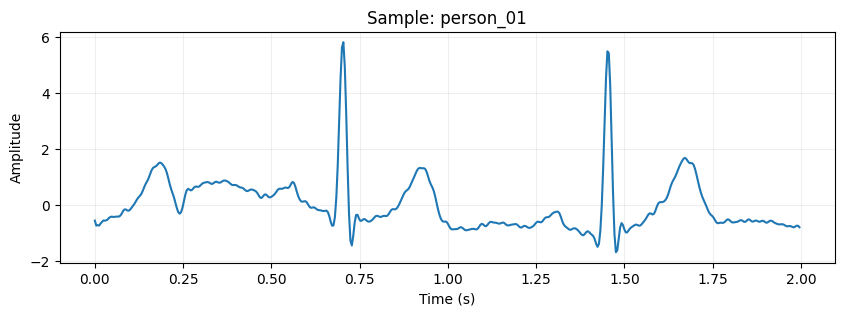

In [ ]:
# Visual sanity check
if len(segments_df):
    sample = segments_df.iloc[0]
    plot_one_signal(sample["signal"], cfg.target_fs, title=f"Sample: {sample['subject_id']}")

## Pair generation for verification

All deep and classical verification demos use same-person versus different-person pairs. In this revised notebook, subjects are split before pair generation so that train, validation, and test sets are subject-independent.


In [ ]:
# =========================
# 7. Pair generation
# =========================
def build_pairs(segments_df, positive_pairs_per_subject=40, negative_pairs_per_subject=40):
    """
    Build same-subject and different-subject verification pairs from a segment dataframe.

    Expected input columns:
        subject_id, record_name, segment_id, signal

    Output columns:
        seg1, seg2, y, subject_1, subject_2

    Notes:
    - Positive pairs: subject_1 == subject_2, y = 1
    - Negative pairs: subject_1 != subject_2, y = 0
    - Pair sampling is random, but reproducible when the global SEED is set before calling.
    """
    by_subj = {s: g.reset_index(drop=True) for s, g in segments_df.groupby("subject_id")}
    subjects = sorted(by_subj.keys())

    pair_columns = ["seg1", "seg2", "y", "subject_1", "subject_2"]
    pairs = []

    # Positive pairs: two different segments from the same subject.
    for s in subjects:
        g = by_subj[s]
        if len(g) < 2:
            continue

        idxs = list(range(len(g)))
        for _ in range(positive_pairs_per_subject):
            i, j = np.random.choice(idxs, size=2, replace=False)
            pairs.append({
                "seg1": g.iloc[i]["signal"],
                "seg2": g.iloc[j]["signal"],
                "y": 1,
                "subject_1": s,
                "subject_2": s
            })

    # Negative pairs: one segment from the claimed subject and one from a different subject.
    for s in subjects:
        g1 = by_subj[s]
        other_subjects = [t for t in subjects if t != s and len(by_subj[t]) > 0]

        if len(g1) == 0 or len(other_subjects) == 0:
            continue

        for _ in range(negative_pairs_per_subject):
            t = random.choice(other_subjects)
            g2 = by_subj[t]

            i = np.random.randint(0, len(g1))
            j = np.random.randint(0, len(g2))

            pairs.append({
                "seg1": g1.iloc[i]["signal"],
                "seg2": g2.iloc[j]["signal"],
                "y": 0,
                "subject_1": s,
                "subject_2": t
            })

    pairs_df = pd.DataFrame(pairs, columns=pair_columns)

    if pairs_df.empty:
        return pairs_df

    return pairs_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)



In [ ]:
# =========================
# 7B. Subject-independent train/validation/test split
# =========================
# This replaces the old pair-row split.
#
# Old protocol:
#     build all pairs first -> split pair rows
#
# New protocol:
#     split subjects first -> build pairs separately inside train/val/test
#
# Result:
#     No subject appears in more than one split.
#
# The downstream notebook flow is preserved because this cell still creates:
#     pairs_df, train_df, val_df, test_df

def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def subject_set_from_pairs(df):
    if df is None or df.empty:
        return set()
    return set(df["subject_1"].unique()) | set(df["subject_2"].unique())


def summarize_pair_split(df, split_name):
    split_subjects = subject_set_from_pairs(df)
    return {
        "Split": split_name,
        "Pairs": len(df),
        "PositivePairs": int((df["y"] == 1).sum()) if len(df) else 0,
        "NegativePairs": int((df["y"] == 0).sum()) if len(df) else 0,
        "PositiveFraction": float(df["y"].mean()) if len(df) else np.nan,
        "UniqueSubjectsInPairs": len(split_subjects),
    }


def build_subject_independent_pair_splits(
    segments_df,
    cfg,
    positive_pairs_per_subject=None,
    negative_pairs_per_subject=None,
    train_frac=0.70,
    val_frac_of_remaining=0.50,
    seed=42,
    verbose=True
):
    """
    Build subject-independent train/validation/test pair dataframes.

    This function intentionally preserves the column format used by the rest of the notebook:
        seg1, seg2, y, subject_1, subject_2

    Parameters
    ----------
    segments_df:
        DataFrame containing ECG segments and subject_id.
    cfg:
        Global configuration object.
    positive_pairs_per_subject, negative_pairs_per_subject:
        Optional overrides. If None, cfg values are used.
    train_frac:
        Fraction of subjects assigned to training.
    val_frac_of_remaining:
        Fraction of remaining subjects assigned to validation.
        With train_frac=0.70 and val_frac_of_remaining=0.50, the split is 70/15/15.
    seed:
        Random seed for reproducibility.
    verbose:
        Whether to print diagnostics and display tables.

    Returns
    -------
    pairs_df, train_df, val_df, test_df, split_info
    """
    set_all_seeds(seed)

    if positive_pairs_per_subject is None:
        positive_pairs_per_subject = cfg.positive_pairs_per_subject
    if negative_pairs_per_subject is None:
        negative_pairs_per_subject = cfg.negative_pairs_per_subject

    subjects = sorted(segments_df["subject_id"].unique())

    if len(subjects) < 3:
        raise ValueError("Need at least 3 subjects for subject-independent train/val/test split.")

    train_subjects, temp_subjects = train_test_split(
        subjects,
        train_size=train_frac,
        random_state=seed,
        shuffle=True
    )

    val_subjects, test_subjects = train_test_split(
        temp_subjects,
        test_size=val_frac_of_remaining,
        random_state=seed,
        shuffle=True
    )

    train_subjects = set(train_subjects)
    val_subjects = set(val_subjects)
    test_subjects = set(test_subjects)

    train_segments = segments_df[segments_df["subject_id"].isin(train_subjects)].reset_index(drop=True)
    val_segments = segments_df[segments_df["subject_id"].isin(val_subjects)].reset_index(drop=True)
    test_segments = segments_df[segments_df["subject_id"].isin(test_subjects)].reset_index(drop=True)

    train_df = build_pairs(
        train_segments,
        positive_pairs_per_subject=positive_pairs_per_subject,
        negative_pairs_per_subject=negative_pairs_per_subject
    ).reset_index(drop=True)

    val_df = build_pairs(
        val_segments,
        positive_pairs_per_subject=positive_pairs_per_subject,
        negative_pairs_per_subject=negative_pairs_per_subject
    ).reset_index(drop=True)

    test_df = build_pairs(
        test_segments,
        positive_pairs_per_subject=positive_pairs_per_subject,
        negative_pairs_per_subject=negative_pairs_per_subject
    ).reset_index(drop=True)

    pairs_df = pd.concat(
        [
            train_df.assign(split="train"),
            val_df.assign(split="validation"),
            test_df.assign(split="test"),
        ],
        ignore_index=True
    )

    split_info = {
        "seed": seed,
        "protocol": "subject_independent",
        "train_subjects": train_subjects,
        "val_subjects": val_subjects,
        "test_subjects": test_subjects,
        "train_segments": train_segments,
        "val_segments": val_segments,
        "test_segments": test_segments,
        "positive_pairs_per_subject": positive_pairs_per_subject,
        "negative_pairs_per_subject": negative_pairs_per_subject,
    }

    split_diagnostics_df = pd.DataFrame([
        summarize_pair_split(train_df, "Train"),
        summarize_pair_split(val_df, "Validation"),
        summarize_pair_split(test_df, "Test"),
    ])

    subject_split_table = pd.DataFrame([
        {
            "Split": "Train",
            "Subjects": len(train_subjects),
            "Segments": len(train_segments),
            "Pairs": len(train_df),
            "PositiveFraction": float(train_df["y"].mean()) if len(train_df) else np.nan,
        },
        {
            "Split": "Validation",
            "Subjects": len(val_subjects),
            "Segments": len(val_segments),
            "Pairs": len(val_df),
            "PositiveFraction": float(val_df["y"].mean()) if len(val_df) else np.nan,
        },
        {
            "Split": "Test",
            "Subjects": len(test_subjects),
            "Segments": len(test_segments),
            "Pairs": len(test_df),
            "PositiveFraction": float(test_df["y"].mean()) if len(test_df) else np.nan,
        },
    ])

    subject_overlap_df = pd.DataFrame([
        {"Comparison": "Train-Val", "OverlapSubjects": len(train_subjects & val_subjects)},
        {"Comparison": "Train-Test", "OverlapSubjects": len(train_subjects & test_subjects)},
        {"Comparison": "Val-Test", "OverlapSubjects": len(val_subjects & test_subjects)},
    ])

    # Hard checks: if any of these fail, the split is not subject-independent.
    assert len(train_subjects & val_subjects) == 0
    assert len(train_subjects & test_subjects) == 0
    assert len(val_subjects & test_subjects) == 0

    # Pair-level checks: every pair inside a split must only contain subjects assigned to that split.
    assert subject_set_from_pairs(train_df).issubset(train_subjects)
    assert subject_set_from_pairs(val_df).issubset(val_subjects)
    assert subject_set_from_pairs(test_df).issubset(test_subjects)

    if verbose:
        print("Subject-independent split completed")
        print("-" * 60)
        print("Random seed:", seed)
        print("Total subjects:", len(subjects))
        print("Train / Validation / Test subjects:", len(train_subjects), len(val_subjects), len(test_subjects))
        print("Train / Validation / Test pairs:", len(train_df), len(val_df), len(test_df))
        print("Class balance:", train_df["y"].mean(), val_df["y"].mean(), test_df["y"].mean())
        print("\nSubject split table")
        display(subject_split_table)
        print("\nPair split diagnostics")
        display(split_diagnostics_df)
        print("\nSubject-overlap diagnostics")
        display(subject_overlap_df)
        print("Verified: no subject overlap across train/validation/test.")

    split_info["subject_split_table"] = subject_split_table
    split_info["split_diagnostics_df"] = split_diagnostics_df
    split_info["subject_overlap_df"] = subject_overlap_df

    return pairs_df, train_df, val_df, test_df, split_info


# Build the main ECG-ID pairs using the strict subject-independent protocol.
pairs_df, train_df, val_df, test_df, subject_split_info = build_subject_independent_pair_splits(
    segments_df=segments_df,
    cfg=cfg,
    positive_pairs_per_subject=cfg.positive_pairs_per_subject,
    negative_pairs_per_subject=cfg.negative_pairs_per_subject,
    train_frac=0.70,
    val_frac_of_remaining=0.50,
    seed=SEED,
    verbose=True
)

pairs_df.head()



Subject-independent split completed
------------------------------------------------------------
Random seed: 42
Total subjects: 90
Train / Validation / Test subjects: 62 14 14
Train / Validation / Test pairs: 4960 1120 1120
Class balance: 0.5 0.5 0.5

Subject split table


,Split,Subjects,Segments,Pairs,PositiveFraction
0,Train,62,3268,4960,0.5
1,Validation,14,684,1120,0.5
2,Test,14,703,1120,0.5



Pair split diagnostics


,Split,Pairs,PositivePairs,NegativePairs,PositiveFraction,UniqueSubjectsInPairs
0,Train,4960,2480,2480,0.5,62
1,Validation,1120,560,560,0.5,14
2,Test,1120,560,560,0.5,14



Subject-overlap diagnostics


,Comparison,OverlapSubjects
0,Train-Val,0
1,Train-Test,0
2,Val-Test,0


Verified: no subject overlap across train/validation/test.


,seg1,seg2,y,subject_1,subject_2,split
0,"[-0.5042085, -0.40944064, -0.1582276, -0.03572...","[0.25406137, 0.47573137, 0.57643294, 0.4380753...",0,person_24,person_18,train
1,"[-2.4690225, -1.8213267, -1.0619564, -0.558777...","[-0.83152026, -0.82434726, -0.72132456, -0.602...",1,person_81,person_81,train
2,"[-0.017262446, -0.12715858, -0.23759846, -0.30...","[-0.49267992, -0.5069501, -0.4984839, -0.46524...",1,person_48,person_48,train
3,"[-0.48823583, -0.62943465, -0.40732944, -0.301...","[-0.34659258, -0.2562688, -0.20296769, -0.2444...",0,person_16,person_52,train
4,"[-0.1336099, 0.28315908, 0.5914344, 0.73833066...","[-0.54509115, -0.6210003, -0.5542482, -0.37872...",1,person_07,person_07,train


# Demo 1 — Handcrafted Features + SVM

This gives you a **classical verification baseline** for your thesis.

Feature idea used here:
- signal mean/std/range
- energy
- first derivative stats
- peak count
- approximate heart-rate proxy
- simple correlation / distance between the two signals

In [ ]:
# =========================
# 8. Demo 1: handcrafted features
# =========================
def extract_single_features(x, fs):
    x = np.asarray(x, dtype=np.float32)
    dx = np.diff(x, prepend=x[0])

    # crude peak detection
    peaks, _ = find_peaks(x, distance=max(1, int(0.25 * fs)))
    rr = np.diff(peaks) / fs if len(peaks) > 1 else np.array([0.0], dtype=np.float32)

    feats = [
        x.mean(), x.std(), x.min(), x.max(), np.ptp(x),
        np.mean(x**2), np.sum(np.abs(dx)), dx.mean(), dx.std(),
        len(peaks),
        rr.mean() if len(rr) else 0.0,
        rr.std() if len(rr) else 0.0,
    ]
    return np.asarray(feats, dtype=np.float32)

def pair_features(seg1, seg2, fs):
    f1 = extract_single_features(seg1, fs)
    f2 = extract_single_features(seg2, fs)
    corr = np.corrcoef(seg1, seg2)[0,1] if np.std(seg1)>1e-8 and np.std(seg2)>1e-8 else 0.0
    dist_l2 = np.linalg.norm(seg1 - seg2)
    dist_l1 = np.abs(seg1 - seg2).mean()
    return np.concatenate([f1, f2, np.abs(f1 - f2), [corr, dist_l2, dist_l1]]).astype(np.float32)

def build_feature_matrix(df, fs):
    X = np.stack([pair_features(r.seg1, r.seg2, fs) for r in df.itertuples(index=False)])
    y = df["y"].values.astype(int)
    return X, y

X_train, y_train = build_feature_matrix(train_df, cfg.target_fs)
X_val, y_val = build_feature_matrix(val_df, cfg.target_fs)
X_test, y_test = build_feature_matrix(test_df, cfg.target_fs)

svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=min(20, X_train.shape[1]))),
    ("svm", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED))
])

svm_clf.fit(X_train, y_train)
svm_val_score = svm_clf.predict_proba(X_val)[:, 1]
svm_test_score = svm_clf.predict_proba(X_test)[:, 1]

demo1_val = compute_metrics(y_val, svm_val_score)
demo1_test = compute_metrics(y_test, svm_test_score, threshold=demo1_val["Threshold"])
print("Demo 1 - Validation:", demo1_val)
print("Demo 1 - Test:", demo1_test)

Demo 1 - Validation: {'ROC_AUC': 0.918313137755102, 'EER': 0.15892857142857142, 'Threshold': 0.5870524548912229, 'Accuracy': 0.8410714285714286, 'FAR': 0.1589285714257334, 'FRR': 0.1589285714257334, 'TP': 471, 'TN': 471, 'FP': 89, 'FN': 89}
Demo 1 - Test: {'ROC_AUC': 0.8760841836734694, 'EER': 0.20267857142857146, 'Threshold': 0.5870524548912229, 'Accuracy': 0.7991071428571429, 'FAR': 0.20357142856779337, 'FRR': 0.19821428571074617, 'TP': 449, 'TN': 446, 'FP': 114, 'FN': 111}


# Deep learning datasets and loaders

In [ ]:
# =========================
# 9. Torch datasets
# =========================
class PairDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x1 = torch.tensor(row["seg1"], dtype=torch.float32).unsqueeze(0)
        x2 = torch.tensor(row["seg2"], dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(row["y"], dtype=torch.float32)
        return x1, x2, y

train_ds = PairDataset(train_df)
val_ds = PairDataset(val_df)
test_ds = PairDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

In [ ]:
# =========================
# 10. Shared training/eval helpers
# =========================
def eval_pair_model(model, loader, device=DEVICE):
    model.eval()
    ys, scores = [], []
    with torch.no_grad():
        for x1, x2, y in loader:
            x1, x2 = x1.to(device), x2.to(device)
            score = model.predict_similarity(x1, x2).detach().cpu().numpy().ravel()
            ys.extend(y.numpy().tolist())
            scores.extend(score.tolist())
    return np.array(ys), np.array(scores)

def train_pair_model(
    model, train_loader, val_loader,
    epochs=5, lr=1e-3, weight_decay=1e-4, device=DEVICE
):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_state = None
    best_auc = -1.0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        n = 0
        for x1, x2, y in train_loader:
            x1, x2, y = x1.to(device), x2.to(device), y.to(device)
            opt.zero_grad()
            loss = model.loss_fn(x1, x2, y)
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(y)
            n += len(y)

        train_loss = total_loss / max(n, 1)
        yv, sv = eval_pair_model(model, val_loader, device=device)
        val_metrics = compute_metrics(yv, sv)
        history.append({"epoch": epoch, "train_loss": train_loss, **val_metrics})

        if val_metrics["ROC_AUC"] > best_auc:
            best_auc = val_metrics["ROC_AUC"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_auc={val_metrics['ROC_AUC']:.4f} | val_eer={val_metrics['EER']:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

# Demo 2 — Lightweight 1D CNN verifier

This is the fast deep baseline.  
Good candidate for real-time deployment.

In [ ]:
# =========================
# 11. Demo 2: Lightweight CNN
# =========================
class ConvEncoder(nn.Module):
    def __init__(self, emb_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16), nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(64, emb_dim)

    def forward(self, x):
        z = self.net(x).squeeze(-1)
        z = self.fc(z)
        z = F.normalize(z, dim=-1)
        return z

class SimpleVerifier(nn.Module):
    def __init__(self, emb_dim=64):
        super().__init__()
        self.encoder = ConvEncoder(emb_dim=emb_dim)
        self.head = nn.Linear(1, 1)

    def forward(self, x1, x2):
        z1 = self.encoder(x1)
        z2 = self.encoder(x2)
        cos = F.cosine_similarity(z1, z2).unsqueeze(-1)
        logit = self.head(cos)
        return logit.squeeze(-1)

    def predict_similarity(self, x1, x2):
        return torch.sigmoid(self.forward(x1, x2))

    def loss_fn(self, x1, x2, y):
        logits = self.forward(x1, x2)
        return F.binary_cross_entropy_with_logits(logits, y)

demo2_model = SimpleVerifier(emb_dim=cfg.embedding_dim)
demo2_model, demo2_hist = train_pair_model(
    demo2_model, train_loader, val_loader,
    epochs=cfg.epochs, lr=cfg.lr, weight_decay=cfg.weight_decay
)

y2, s2 = eval_pair_model(demo2_model, test_loader)
demo2_test = compute_metrics(y2, s2)
print("Demo 2 Test:", demo2_test)
print("Demo 2 Params:", count_parameters(demo2_model))

Epoch 01 | train_loss=0.6964 | val_auc=0.2923 | val_eer=0.6616
Epoch 02 | train_loss=0.6941 | val_auc=0.3406 | val_eer=0.6107
Epoch 03 | train_loss=0.6934 | val_auc=0.3110 | val_eer=0.6429
Epoch 04 | train_loss=0.6933 | val_auc=0.2814 | val_eer=0.6777
Epoch 05 | train_loss=0.6933 | val_auc=0.3466 | val_eer=0.6152
Epoch 06 | train_loss=0.6932 | val_auc=0.3482 | val_eer=0.6089
Epoch 07 | train_loss=0.6932 | val_auc=0.2617 | val_eer=0.6848
Epoch 08 | train_loss=0.6932 | val_auc=0.3314 | val_eer=0.6420
Demo 2 Test: {'ROC_AUC': 0.3229862882653061, 'EER': 0.6241071428571429, 'Threshold': 0.5017691850662231, 'Accuracy': 0.37589285714285714, 'FAR': 0.6232142857031568, 'FRR': 0.6249999999888393, 'TP': 210, 'TN': 211, 'FP': 349, 'FN': 350}
Demo 2 Params: 17410


# Demo 3 — Siamese CNN-BiLSTM verifier

This is the stronger sequence-aware baseline.

In [ ]:
# =========================
# 12. Demo 3: Siamese CNN-BiLSTM
# =========================
class SiameseCNNBiLSTMEncoder(nn.Module):
    def __init__(self, emb_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 5, padding=2), nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=32,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(64, emb_dim)

    def forward(self, x):
        h = self.conv(x)               # [B, C, T]
        h = h.transpose(1, 2)          # [B, T, C]
        out, _ = self.lstm(h)
        z = out[:, -1, :]
        z = self.fc(z)
        z = F.normalize(z, dim=-1)
        return z

class SiameseVerifier(nn.Module):
    def __init__(self, emb_dim=64):
        super().__init__()
        self.encoder = SiameseCNNBiLSTMEncoder(emb_dim=emb_dim)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )

    def forward(self, x1, x2):
        z1 = self.encoder(x1)
        z2 = self.encoder(x2)
        feat = torch.cat([z1, z2, torch.abs(z1 - z2), z1 * z2], dim=-1)
        return self.classifier(feat).squeeze(-1)

    def predict_similarity(self, x1, x2):
        return torch.sigmoid(self.forward(x1, x2))

    def loss_fn(self, x1, x2, y):
        logits = self.forward(x1, x2)
        return F.binary_cross_entropy_with_logits(logits, y)

demo3_model = SiameseVerifier(emb_dim=cfg.embedding_dim)
demo3_model, demo3_hist = train_pair_model(
    demo3_model, train_loader, val_loader,
    epochs=cfg.epochs, lr=cfg.lr, weight_decay=cfg.weight_decay
)

y3, s3 = eval_pair_model(demo3_model, test_loader)
demo3_test = compute_metrics(y3, s3)
print("Demo 3 Test:", demo3_test)
print("Demo 3 Params:", count_parameters(demo3_model))

Epoch 01 | train_loss=0.6940 | val_auc=0.4937 | val_eer=0.5116
Epoch 02 | train_loss=0.6935 | val_auc=0.5078 | val_eer=0.4857
Epoch 03 | train_loss=0.6931 | val_auc=0.4990 | val_eer=0.4955
Epoch 04 | train_loss=0.6921 | val_auc=0.5097 | val_eer=0.4946
Epoch 05 | train_loss=0.6913 | val_auc=0.5358 | val_eer=0.4589
Epoch 06 | train_loss=0.6928 | val_auc=0.5146 | val_eer=0.4839
Epoch 07 | train_loss=0.6893 | val_auc=0.5314 | val_eer=0.4777
Epoch 08 | train_loss=0.6722 | val_auc=0.7336 | val_eer=0.3330
Demo 3 Test: {'ROC_AUC': 0.6184438775510204, 'EER': 0.4133928571428571, 'Threshold': 0.5299551486968994, 'Accuracy': 0.5866071428571429, 'FAR': 0.4124999999926339, 'FRR': 0.41428571427831634, 'TP': 328, 'TN': 329, 'FP': 231, 'FN': 232}
Demo 3 Params: 40289


# Demo 4 — Proposed PINN-inspired verifier

This is the placeholder for your thesis contribution.

The model below combines:

- verification loss
- optional reconstruction loss
- smoothness / derivative consistency penalty
- morphology regularization on the latent representation

You can later replace the regularization block with your exact **HDCC/PINN ECG residual**.

In [ ]:
# =========================
# 13. Demo 4: Proposed PINN-inspired model
# =========================
class PINNEncoder(nn.Module):
    def __init__(self, emb_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, 9, padding=4), nn.BatchNorm1d(16), nn.ReLU(),
            nn.Conv1d(16, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.emb = nn.Linear(64, emb_dim)
        self.recon = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Linear(128, int(cfg.segment_seconds * cfg.target_fs))
        )

    def forward(self, x):
        h = self.conv(x)
        pooled = h.mean(dim=-1)
        z = F.normalize(self.emb(pooled), dim=-1)
        recon = self.recon(z)
        return z, recon

class ProposedPINNVerifier(nn.Module):
    def __init__(self, emb_dim=64, alpha=1.0, beta=0.2, gamma=0.1, delta=0.05):
        super().__init__()
        self.encoder = PINNEncoder(emb_dim=emb_dim)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 4, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.delta = delta

    def forward(self, x1, x2):
        z1, r1 = self.encoder(x1)
        z2, r2 = self.encoder(x2)
        feat = torch.cat([z1, z2, torch.abs(z1 - z2), z1 * z2], dim=-1)
        logits = self.classifier(feat).squeeze(-1)
        return logits, z1, z2, r1, r2

    def predict_similarity(self, x1, x2):
        logits, _, _, _, _ = self.forward(x1, x2)
        return torch.sigmoid(logits)

    def smoothness_penalty(self, x):
        dx = x[:, :, 1:] - x[:, :, :-1]
        ddx = dx[:, :, 1:] - dx[:, :, :-1]
        return ddx.abs().mean()

    def beat_consistency_penalty(self, recon, target):
        # Encourage morphology consistency in first derivative
        dr = recon[:, 1:] - recon[:, :-1]
        dt = target[:, 1:] - target[:, :-1]
        return F.l1_loss(dr, dt)

    def loss_fn(self, x1, x2, y):
        logits, z1, z2, r1, r2 = self.forward(x1, x2)
        verify_loss = F.binary_cross_entropy_with_logits(logits, y)

        target1 = x1.squeeze(1)
        target2 = x2.squeeze(1)

        recon_loss = F.mse_loss(r1, target1) + F.mse_loss(r2, target2)
        smooth_loss = self.smoothness_penalty(x1) + self.smoothness_penalty(x2)
        morph_loss = self.beat_consistency_penalty(r1, target1) + self.beat_consistency_penalty(r2, target2)

        total = (
            self.alpha * verify_loss
            + self.beta * recon_loss
            + self.gamma * smooth_loss
            + self.delta * morph_loss
        )
        return total

demo4_model = ProposedPINNVerifier(
    emb_dim=cfg.embedding_dim,
    alpha=1.0, beta=0.15, gamma=0.05, delta=0.05
)

demo4_model, demo4_hist = train_pair_model(
    demo4_model, train_loader, val_loader,
    epochs=cfg.epochs, lr=cfg.lr, weight_decay=cfg.weight_decay
)

y4, s4 = eval_pair_model(demo4_model, test_loader)
demo4_test = compute_metrics(y4, s4)
print("Demo 4 Test:", demo4_test)
print("Demo 4 Params:", count_parameters(demo4_model))

# Preserve the PINN-only result before the later HDC baseline reuses the name demo4_test.
# This prevents the ablation tables from accidentally using HDC metrics as the PINN-only baseline.
demo4_pinn_model = demo4_model
demo4_pinn_test = demo4_test.copy()
demo4_pinn_params = count_parameters(demo4_pinn_model)

print("Saved PINN-only metrics for ablation:", demo4_pinn_test)
print("Saved PINN-only params:", demo4_pinn_params)

Epoch 01 | train_loss=0.8805 | val_auc=0.9443 | val_eer=0.1071
Epoch 02 | train_loss=0.6244 | val_auc=0.9511 | val_eer=0.1250
Epoch 03 | train_loss=0.5524 | val_auc=0.9647 | val_eer=0.1018
Epoch 04 | train_loss=0.5330 | val_auc=0.9527 | val_eer=0.1170
Epoch 05 | train_loss=0.4975 | val_auc=0.9635 | val_eer=0.1027
Epoch 06 | train_loss=0.4834 | val_auc=0.9639 | val_eer=0.0804
Epoch 07 | train_loss=0.4641 | val_auc=0.9693 | val_eer=0.0804
Epoch 08 | train_loss=0.4709 | val_auc=0.9709 | val_eer=0.0786
Demo 4 Test: {'ROC_AUC': 0.9675956632653061, 'EER': 0.0830357142857143, 'Threshold': 0.2636171281337738, 'Accuracy': 0.9169642857142857, 'FAR': 0.0839285714270727, 'FRR': 0.0821428571413903, 'TP': 514, 'TN': 513, 'FP': 47, 'FN': 46}
Demo 4 Params: 107797
Saved PINN-only metrics for ablation: {'ROC_AUC': 0.9675956632653061, 'EER': 0.0830357142857143, 'Threshold': 0.2636171281337738, 'Accuracy': 0.9169642857142857, 'FAR': 0.0839285714270727, 'FRR': 0.0821428571413903, 'TP': 514, 'TN': 513, 'FP

# Demo 4 — HDC baseline for fast ECG authentication

This section adds a true **HDC-style baseline** to the notebook.

## Idea

For each ECG segment we:
- split into local chunks
- extract lightweight local features
- quantize/sign them
- bind them with random position hypervectors
- bundle them into one fixed-size hypervector

For verification:
- encode both segments
- compare them with cosine similarity
- optionally learn a simple threshold on validation data

This gives you a much more thesis-aligned **fast authentication baseline**.

In [ ]:
# =========================
# 13A. Demo 4: HDC baseline
# =========================
class HDCEncoder:
    def __init__(self, signal_len, chunk_size=16, hv_dim=2000, seed=42):
        self.signal_len = signal_len
        self.chunk_size = chunk_size
        self.hv_dim = hv_dim
        self.rng = np.random.default_rng(seed)

        self.num_chunks = signal_len // chunk_size
        if self.num_chunks < 1:
            raise ValueError("chunk_size too large for signal length")

        # Random bipolar position hypervectors
        self.pos_hv = self.rng.choice([-1.0, 1.0], size=(self.num_chunks, hv_dim)).astype(np.float32)

        # Random projection from local feature vector to hv space
        self.local_feat_dim = 8
        self.proj = self.rng.normal(0, 1, size=(self.local_feat_dim, hv_dim)).astype(np.float32)

    def _local_features(self, chunk):
        chunk = chunk.astype(np.float32)
        d1 = np.diff(chunk, prepend=chunk[0])
        feats = np.array([
            chunk.mean(),
            chunk.std(),
            chunk.min(),
            chunk.max(),
            np.ptp(chunk),
            np.mean(chunk**2),
            d1.mean(),
            d1.std()
        ], dtype=np.float32)
        return feats

    def encode_one(self, signal_1d):
        x = np.asarray(signal_1d, dtype=np.float32)
        usable = self.num_chunks * self.chunk_size
        x = x[:usable]
        chunks = x.reshape(self.num_chunks, self.chunk_size)

        hv_sum = np.zeros(self.hv_dim, dtype=np.float32)
        for i in range(self.num_chunks):
            feats = self._local_features(chunks[i])
            feat_hv = feats @ self.proj                       # [hv_dim]
            feat_hv = np.where(feat_hv >= 0, 1.0, -1.0).astype(np.float32)
            bound = feat_hv * self.pos_hv[i]                 # bind with position
            hv_sum += bound                                  # bundle

        hv = np.where(hv_sum >= 0, 1.0, -1.0).astype(np.float32)
        norm = np.linalg.norm(hv) + 1e-8
        return hv / norm

    def similarity(self, sig1, sig2):
        h1 = self.encode_one(sig1)
        h2 = self.encode_one(sig2)
        return float(np.dot(h1, h2))

segment_len = int(cfg.segment_seconds * cfg.target_fs)
hdc_encoder = HDCEncoder(signal_len=segment_len, chunk_size=16, hv_dim=2000, seed=SEED)

def eval_hdc_dataframe(df, encoder):
    y_true, y_score = [], []
    for row in df.itertuples(index=False):
        score = encoder.similarity(row.seg1, row.seg2)
        y_true.append(int(row.y))
        y_score.append(score)
    return np.array(y_true), np.array(y_score)

y4_hdc_val, s4_hdc_val = eval_hdc_dataframe(val_df, hdc_encoder)
demo4_val = compute_metrics(y4_hdc_val, s4_hdc_val)

y4_hdc_test, s4_hdc_test = eval_hdc_dataframe(test_df, hdc_encoder)
demo4_test = compute_metrics(y4_hdc_test, s4_hdc_test, threshold=demo4_val["Threshold"])

print("Demo 4 (HDC) - Validation:", demo4_val)
print("Demo 4 (HDC) - Test:", demo4_test)

Demo 4 (HDC) - Validation: {'ROC_AUC': 0.5431696428571429, 'EER': 0.4616071428571429, 'Threshold': 0.4350000023841858, 'Accuracy': 0.5383928571428571, 'FAR': 0.46071428570605866, 'FRR': 0.4624999999917411, 'TP': 301, 'TN': 302, 'FP': 258, 'FN': 259}
Demo 4 (HDC) - Test: {'ROC_AUC': 0.529969706632653, 'EER': 0.4892857142857143, 'Threshold': 0.4350000023841858, 'Accuracy': 0.5169642857142858, 'FAR': 0.33214285713692604, 'FRR': 0.6339285714172512, 'TP': 205, 'TN': 374, 'FP': 186, 'FN': 355}


# Demo 5 — HDC + PINN hybrid with explicit physics residual

This is the thesis-oriented hybrid model.

## Design
- CNN encoder learns a compact ECG representation
- HDC branch converts the latent representation into a fixed hypervector
- verification is done using both:
  - neural similarity features
  - HDC similarity
- the PINN branch predicts:
  - \(v(t)\), a reconstructed ECG-like trajectory
  - \(w(t)\), an auxiliary recovery state
- the physics term enforces a simplified FitzHugh–Nagumo residual

So this becomes:

**fast fixed-dimension HDC representation + physiology-aware verification + explicit ODE-based PINN loss**

## Physics block used in Demo 5

The hybrid model now predicts:
- a reconstruction \(v(t)\)
- an auxiliary hidden recovery variable \(w(t)\)

Then it computes finite-difference approximations of:

\[
\frac{dv}{dt}, \quad \frac{dw}{dt}
\]

and penalizes deviation from the FitzHugh–Nagumo dynamics:

\[
\frac{dv}{dt} - \left(v - \frac{v^3}{3} - w + I\right)
\]

\[
\frac{dw}{dt} - \epsilon (v + a - bw)
\]

So the total hybrid loss becomes:

\[
L
=
\alpha L_{\text{verify}}
+
\beta L_{\text{recon}}
+
\gamma L_{\text{smooth}}
+
\delta L_{\text{morph}}
+
\eta L_{\text{HDC}}
+
\zeta L_{\text{phys}}
\]

This is much closer to a real thesis PINN than a generic regularizer.

In [ ]:
# =========================
# 13B. Demo 5: HDC + PINN hybrid with explicit FHN residual
# =========================
class LatentHDCProjector(nn.Module):
    def __init__(self, in_dim=64, hv_dim=2000):
        super().__init__()
        self.register_buffer("proj", torch.randn(in_dim, hv_dim))
        self.hv_dim = hv_dim

    def forward(self, z):
        h = z @ self.proj
        h = torch.sign(h)
        h[h == 0] = 1.0
        h = F.normalize(h, dim=-1)
        return h

class PINNEncoderFHN(nn.Module):
    """
    Encoder that outputs:
    - latent embedding z
    - reconstructed v(t)
    - auxiliary recovery variable w(t)

    We use these sequences to build an explicit FitzHugh-Nagumo residual.
    """
    def __init__(self, emb_dim=64, seq_len=None):
        super().__init__()
        if seq_len is None:
            seq_len = int(cfg.segment_seconds * cfg.target_fs)

        self.seq_len = seq_len

        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, 9, padding=4), nn.BatchNorm1d(16), nn.ReLU(),
            nn.Conv1d(16, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.emb = nn.Linear(64, emb_dim)

        self.v_head = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Linear(128, seq_len)
        )

        self.w_head = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Linear(128, seq_len)
        )

        self.I_param = nn.Parameter(torch.tensor(0.1, dtype=torch.float32))

    def forward(self, x):
        h = self.conv(x)
        pooled = h.mean(dim=-1)
        z = F.normalize(self.emb(pooled), dim=-1)
        v = self.v_head(z)
        w = self.w_head(z)
        return z, v, w

class HybridHDCPINNVerifierFHN(nn.Module):
    def __init__(
        self,
        emb_dim=64,
        hv_dim=2000,
        alpha=1.0,
        beta=0.15,
        gamma=0.05,
        delta=0.05,
        eta=0.25,
        zeta=0.20,
        fhn_eps=0.08,
        fhn_a=0.7,
        fhn_b=0.8,
    ):
        super().__init__()
        self.seq_len = int(cfg.segment_seconds * cfg.target_fs)
        self.dt = 1.0 / cfg.target_fs

        self.encoder = PINNEncoderFHN(emb_dim=emb_dim, seq_len=self.seq_len)
        self.hdc = LatentHDCProjector(in_dim=emb_dim, hv_dim=hv_dim)

        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 4 + 1, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.delta = delta
        self.eta = eta
        self.zeta = zeta

        self.fhn_eps = fhn_eps
        self.fhn_a = fhn_a
        self.fhn_b = fhn_b

    def finite_diff(self, x):
        return (x[:, 1:] - x[:, :-1]) / self.dt

    def fhn_physics_loss(self, v, w):
        """
        FHN residual:
            dv/dt = v - v^3/3 - w + I
            dw/dt = eps * (v + a - b w)

        We evaluate on T-1 points using finite differences.
        """
        dv_dt = self.finite_diff(v)
        dw_dt = self.finite_diff(w)

        v_mid = v[:, :-1]
        w_mid = w[:, :-1]
        I = self.encoder.I_param

        rhs_v = v_mid - (v_mid ** 3) / 3.0 - w_mid + I
        rhs_w = self.fhn_eps * (v_mid + self.fhn_a - self.fhn_b * w_mid)

        res_v = dv_dt - rhs_v
        res_w = dw_dt - rhs_w

        return torch.mean(res_v ** 2) + torch.mean(res_w ** 2)

    def forward(self, x1, x2):
        z1, v1, w1 = self.encoder(x1)
        z2, v2, w2 = self.encoder(x2)

        h1 = self.hdc(z1)
        h2 = self.hdc(z2)
        hdc_sim = F.cosine_similarity(h1, h2).unsqueeze(-1)

        feat = torch.cat([z1, z2, torch.abs(z1 - z2), z1 * z2, hdc_sim], dim=-1)
        logits = self.classifier(feat).squeeze(-1)

        return logits, z1, z2, h1, h2, v1, w1, v2, w2

    def predict_similarity(self, x1, x2):
        logits, *_ = self.forward(x1, x2)
        return torch.sigmoid(logits)

    def smoothness_penalty(self, x):
        dx = x[:, :, 1:] - x[:, :, :-1]
        ddx = dx[:, :, 1:] - dx[:, :, :-1]
        return ddx.abs().mean()

    def beat_consistency_penalty(self, recon, target):
        dr = recon[:, 1:] - recon[:, :-1]
        dt = target[:, 1:] - target[:, :-1]
        return F.l1_loss(dr, dt)

    def loss_fn(self, x1, x2, y):
        logits, z1, z2, h1, h2, v1, w1, v2, w2 = self.forward(x1, x2)

        verify_loss = F.binary_cross_entropy_with_logits(logits, y)

        target1 = x1.squeeze(1)
        target2 = x2.squeeze(1)

        recon_loss = F.mse_loss(v1, target1) + F.mse_loss(v2, target2)
        smooth_loss = self.smoothness_penalty(x1) + self.smoothness_penalty(x2)
        morph_loss = self.beat_consistency_penalty(v1, target1) + self.beat_consistency_penalty(v2, target2)

        hdc_cos = F.cosine_similarity(h1, h2)
        hdc_target = y * 2.0 - 1.0
        hdc_loss = F.mse_loss(hdc_cos, hdc_target)

        phys_loss = self.fhn_physics_loss(v1, w1) + self.fhn_physics_loss(v2, w2)

        total = (
            self.alpha * verify_loss
            + self.beta * recon_loss
            + self.gamma * smooth_loss
            + self.delta * morph_loss
            + self.eta * hdc_loss
            + self.zeta * phys_loss
        )
        return total

demo5_model = HybridHDCPINNVerifierFHN(
    emb_dim=cfg.embedding_dim,
    hv_dim=2000,
    alpha=1.0,
    beta=0.15,
    gamma=0.05,
    delta=0.05,
    eta=0.25,
    zeta=0.20,
    fhn_eps=0.08,
    fhn_a=0.7,
    fhn_b=0.8,
)

demo5_model, demo5_hist = train_pair_model(
    demo5_model, train_loader, val_loader,
    epochs=cfg.epochs, lr=cfg.lr, weight_decay=cfg.weight_decay
)

y5, s5 = eval_pair_model(demo5_model, test_loader)
demo5_test = compute_metrics(y5, s5)
print("Demo 5 Test:", demo5_test)
print("Demo 5 Params:", count_parameters(demo5_model))
print("Learned I parameter:", float(demo5_model.encoder.I_param.detach().cpu()))

Epoch 01 | train_loss=29.5885 | val_auc=0.8432 | val_eer=0.2330
Epoch 02 | train_loss=1.6258 | val_auc=0.8242 | val_eer=0.2473
Epoch 03 | train_loss=1.5391 | val_auc=0.8188 | val_eer=0.2500
Epoch 04 | train_loss=1.5042 | val_auc=0.8248 | val_eer=0.2661
Epoch 05 | train_loss=1.4204 | val_auc=0.8741 | val_eer=0.2107
Epoch 06 | train_loss=1.2795 | val_auc=0.9123 | val_eer=0.1687
Epoch 07 | train_loss=1.1938 | val_auc=0.9309 | val_eer=0.1411
Epoch 08 | train_loss=1.1521 | val_auc=0.9355 | val_eer=0.1330
Demo 5 Test: {'ROC_AUC': 0.9237882653061226, 'EER': 0.15714285714285714, 'Threshold': 0.5968444347381592, 'Accuracy': 0.8428571428571429, 'FAR': 0.15714285714005102, 'FRR': 0.15714285714005102, 'TP': 472, 'TN': 472, 'FP': 88, 'FN': 88}
Demo 5 Params: 180682
Learned I parameter: -0.003285215934738517


# Demo 6 — HDC + PINN hybrid with McSharry-inspired ECG physics

This demo keeps the **same hybrid HDC + PINN authentication architecture** but replaces the
FitzHugh–Nagumo residual with a more ECG-morphology-aware **McSharry-inspired** residual.

Why this matters for the thesis:
- Demo 5 uses a generic excitable-dynamics prior (FHN)
- Demo 6 uses an ECG-shaped morphology prior
- comparing them helps answer whether a **more ECG-specific physics prior** improves biometric verification

Practical note:
This is a **McSharry-inspired thesis implementation**, not a full ECGSYN reproduction.
The goal here is to make the physics block more morphology-aware while keeping the notebook
tractable and comparable to the FHN version.


In [ ]:

# =========================
# 13C. Demo 6: HDC + PINN hybrid with McSharry-inspired ECG residual
# =========================
class PINNEncoderMcSharry(nn.Module):
    '''
    Encoder that outputs:
    - latent embedding z
    - reconstructed ECG-like trajectory s(t)

    Compared with the FHN version, this branch focuses on a single reconstructed ECG waveform
    and imposes a McSharry-inspired morphology residual on it.
    '''
    def __init__(self, emb_dim=64, seq_len=None):
        super().__init__()
        if seq_len is None:
            seq_len = int(cfg.segment_seconds * cfg.target_fs)

        self.seq_len = seq_len

        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, 9, padding=4), nn.BatchNorm1d(16), nn.ReLU(),
            nn.Conv1d(16, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),
        )

        self.emb = nn.Linear(64, emb_dim)
        self.sig_head = nn.Sequential(
            nn.Linear(emb_dim, 128),
            nn.ReLU(),
            nn.Linear(128, seq_len)
        )

        self.z0 = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

    def forward(self, x):
        h = self.conv(x)
        pooled = h.mean(dim=-1)
        z = F.normalize(self.emb(pooled), dim=-1)
        s = self.sig_head(z)
        return z, s


class HybridHDCPINNVerifierMcSharry(nn.Module):
    def __init__(
        self,
        emb_dim=64,
        hv_dim=2000,
        alpha=1.0,
        beta=0.15,
        gamma=0.05,
        delta=0.05,
        eta=0.25,
        zeta=0.20,
    ):
        super().__init__()
        self.seq_len = int(cfg.segment_seconds * cfg.target_fs)
        self.dt = 1.0 / cfg.target_fs
        self.encoder = PINNEncoderMcSharry(emb_dim=emb_dim, seq_len=self.seq_len)
        self.hdc = LatentHDCProjector(in_dim=emb_dim, hv_dim=hv_dim)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 4 + 1, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.delta = delta
        self.eta = eta
        self.zeta = zeta

        theta_vals = torch.tensor([
            -0.70 * math.pi,
            -0.15 * math.pi,
             0.00 * math.pi,
             0.12 * math.pi,
             0.55 * math.pi,
        ], dtype=torch.float32)
        a_vals = torch.tensor([0.10, -0.12, 1.00, -0.25, 0.35], dtype=torch.float32)
        b_vals = torch.tensor([0.22, 0.08, 0.05, 0.08, 0.25], dtype=torch.float32)

        self.register_buffer("theta_i", theta_vals)
        self.register_buffer("a_i", a_vals)
        self.register_buffer("b_i", b_vals)

    def finite_diff(self, x):
        return (x[:, 1:] - x[:, :-1]) / self.dt

    def wrapped_angle(self, angle):
        return torch.atan2(torch.sin(angle), torch.cos(angle))

    def mcsharry_physics_loss(self, s):
        '''
        McSharry-inspired residual:
            ds/dt = - sum_i a_i * dtheta_i * exp( -dtheta_i^2 / (2 b_i^2) ) - (s - z0)

        This is not a full ECGSYN reproduction, but it gives a morphology-aware residual.
        '''
        device = s.device
        B, T = s.shape
        theta = torch.linspace(-math.pi, math.pi, T - 1, device=device).unsqueeze(0).repeat(B, 1)
        ds_dt = self.finite_diff(s)
        s_mid = s[:, :-1]

        rhs = torch.zeros_like(s_mid)
        for k in range(len(self.theta_i)):
            dtheta = self.wrapped_angle(theta - self.theta_i[k])
            rhs = rhs - self.a_i[k] * dtheta * torch.exp(-(dtheta ** 2) / (2.0 * (self.b_i[k] ** 2)))

        rhs = rhs - (s_mid - self.encoder.z0)
        res = ds_dt - rhs
        return torch.mean(res ** 2)

    def forward(self, x1, x2):
        z1, s1 = self.encoder(x1)
        z2, s2 = self.encoder(x2)

        h1 = self.hdc(z1)
        h2 = self.hdc(z2)
        hdc_sim = F.cosine_similarity(h1, h2).unsqueeze(-1)

        feat = torch.cat([z1, z2, torch.abs(z1 - z2), z1 * z2, hdc_sim], dim=-1)
        logits = self.classifier(feat).squeeze(-1)
        return logits, z1, z2, h1, h2, s1, s2

    def predict_similarity(self, x1, x2):
        logits, *_ = self.forward(x1, x2)
        return torch.sigmoid(logits)

    def smoothness_penalty(self, x):
        dx = x[:, :, 1:] - x[:, :, :-1]
        ddx = dx[:, :, 1:] - dx[:, :, :-1]
        return ddx.abs().mean()

    def beat_consistency_penalty(self, recon, target):
        dr = recon[:, 1:] - recon[:, :-1]
        dt = target[:, 1:] - target[:, :-1]
        return F.l1_loss(dr, dt)

    def loss_fn(self, x1, x2, y):
        logits, z1, z2, h1, h2, s1, s2 = self.forward(x1, x2)

        verify_loss = F.binary_cross_entropy_with_logits(logits, y)
        target1 = x1.squeeze(1)
        target2 = x2.squeeze(1)
        recon_loss = F.mse_loss(s1, target1) + F.mse_loss(s2, target2)
        smooth_loss = self.smoothness_penalty(x1) + self.smoothness_penalty(x2)
        morph_loss = self.beat_consistency_penalty(s1, target1) + self.beat_consistency_penalty(s2, target2)

        hdc_cos = F.cosine_similarity(h1, h2)
        hdc_target = y * 2.0 - 1.0
        hdc_loss = F.mse_loss(hdc_cos, hdc_target)

        phys_loss = self.mcsharry_physics_loss(s1) + self.mcsharry_physics_loss(s2)

        total = (
            self.alpha * verify_loss
            + self.beta * recon_loss
            + self.gamma * smooth_loss
            + self.delta * morph_loss
            + self.eta * hdc_loss
            + self.zeta * phys_loss
        )
        return total

demo6_model = HybridHDCPINNVerifierMcSharry(
    emb_dim=cfg.embedding_dim,
    hv_dim=2000,
    alpha=1.0,
    beta=0.15,
    gamma=0.05,
    delta=0.05,
    eta=0.25,
    zeta=0.20,
)
demo6_model, demo6_hist = train_pair_model(
    demo6_model, train_loader, val_loader,
    epochs=cfg.epochs, lr=cfg.lr, weight_decay=cfg.weight_decay
)
y6, s6 = eval_pair_model(demo6_model, test_loader)
demo6_test = compute_metrics(y6, s6)
print("Demo 6 Test:", demo6_test)
print("Demo 6 Params:", count_parameters(demo6_model))
print("Learned z0 parameter:", float(demo6_model.encoder.z0.detach().cpu()))




Epoch 01 | train_loss=15.5418 | val_auc=0.8481 | val_eer=0.2080
Epoch 02 | train_loss=1.5610 | val_auc=0.8501 | val_eer=0.2223
Epoch 03 | train_loss=1.4904 | val_auc=0.8616 | val_eer=0.2143
Epoch 04 | train_loss=1.3570 | val_auc=0.9036 | val_eer=0.1634
Epoch 05 | train_loss=1.1895 | val_auc=0.9337 | val_eer=0.1232
Epoch 06 | train_loss=1.1122 | val_auc=0.9440 | val_eer=0.1125
Epoch 07 | train_loss=1.0694 | val_auc=0.9540 | val_eer=0.1018
Epoch 08 | train_loss=1.0299 | val_auc=0.9563 | val_eer=0.1054
Demo 6 Test: {'ROC_AUC': 0.9311543367346939, 'EER': 0.1339285714285714, 'Threshold': 0.5187493562698364, 'Accuracy': 0.8660714285714286, 'FAR': 0.13392857142617984, 'FRR': 0.13392857142617984, 'TP': 485, 'TN': 485, 'FP': 75, 'FN': 75}
Demo 6 Params: 107862
Learned z0 parameter: 0.0021750587038695812


# Thesis ablation study — what actually helps?

This is the most important extra section for turning the notebook into a stronger thesis.

It answers:

- does the **physics residual** help?
- does the **HDC branch / HDC loss** help?
- is the **full hybrid** better than a PINN-only verifier?

A strong thesis should not only report the best model; it should also explain **why** that model works.

In [ ]:
# =========================
# 13C. Thesis ablation study
# =========================

# We reuse Demo 4 as the PINN-only baseline (no HDC branch)
# and Demo 5 as the full hybrid model.

ablation_rows = []

# A0: PINN-only baseline (saved before Demo 4 HDC overwrites demo4_test)
ablation_rows.append({
    "Variant": "A0_PINN_only",
    "Uses_HDC": False,
    "Uses_Physics": False,
    "Uses_Recon": True,
    "Uses_Morph": True,
    "Uses_Smooth": True,
    "Params": demo4_pinn_params,
    **demo4_pinn_test,
})

# A1: Hybrid without physics residual
ablation_no_phys = HybridHDCPINNVerifierFHN(
    emb_dim=cfg.embedding_dim,
    hv_dim=2000,
    alpha=1.0,
    beta=0.15,
    gamma=0.05,
    delta=0.05,
    eta=0.25,
    zeta=0.0,   # remove explicit physics term
    fhn_eps=0.08,
    fhn_a=0.7,
    fhn_b=0.8,
)
ablation_no_phys, ablation_no_phys_hist = train_pair_model(
    ablation_no_phys, train_loader, val_loader,
    epochs=cfg.epochs, lr=cfg.lr, weight_decay=cfg.weight_decay
)
y_no_phys, s_no_phys = eval_pair_model(ablation_no_phys, test_loader)
ablation_no_phys_test = compute_metrics(y_no_phys, s_no_phys)
ablation_rows.append({
    "Variant": "A1_Hybrid_no_physics",
    "Uses_HDC": True,
    "Uses_Physics": False,
    "Uses_Recon": True,
    "Uses_Morph": True,
    "Uses_Smooth": True,
    "Params": count_parameters(ablation_no_phys),
    **ablation_no_phys_test,
})

# A2: Hybrid without HDC supervision term
ablation_no_hdc_loss = HybridHDCPINNVerifierFHN(
    emb_dim=cfg.embedding_dim,
    hv_dim=2000,
    alpha=1.0,
    beta=0.15,
    gamma=0.05,
    delta=0.05,
    eta=0.0,    # remove HDC similarity supervision
    zeta=0.20,
    fhn_eps=0.08,
    fhn_a=0.7,
    fhn_b=0.8,
)
ablation_no_hdc_loss, ablation_no_hdc_loss_hist = train_pair_model(
    ablation_no_hdc_loss, train_loader, val_loader,
    epochs=cfg.epochs, lr=cfg.lr, weight_decay=cfg.weight_decay
)
y_no_hdc, s_no_hdc = eval_pair_model(ablation_no_hdc_loss, test_loader)
ablation_no_hdc_test = compute_metrics(y_no_hdc, s_no_hdc)
ablation_rows.append({
    "Variant": "A2_Hybrid_no_HDC_loss",
    "Uses_HDC": True,
    "Uses_Physics": True,
    "Uses_Recon": True,
    "Uses_Morph": True,
    "Uses_Smooth": True,
    "Params": count_parameters(ablation_no_hdc_loss),
    **ablation_no_hdc_test,
})

# A3: Full hybrid (already trained above as demo5_model)
ablation_rows.append({
    "Variant": "A3_Full_HDC_PINN_hybrid",
    "Uses_HDC": True,
    "Uses_Physics": True,
    "Uses_Recon": True,
    "Uses_Morph": True,
    "Uses_Smooth": True,
    "Params": count_parameters(demo5_model),
    **demo5_test,
})

ablation_df = pd.DataFrame(ablation_rows)
print("Ablation summary")
display(ablation_df.sort_values("ROC_AUC", ascending=False))

Epoch 01 | train_loss=1.1271 | val_auc=0.9386 | val_eer=0.1080
Epoch 02 | train_loss=0.8070 | val_auc=0.9539 | val_eer=0.1098
Epoch 03 | train_loss=0.7424 | val_auc=0.9615 | val_eer=0.0911
Epoch 04 | train_loss=0.7136 | val_auc=0.9606 | val_eer=0.0973
Epoch 05 | train_loss=0.6890 | val_auc=0.9706 | val_eer=0.0696
Epoch 06 | train_loss=0.6804 | val_auc=0.9667 | val_eer=0.0696
Epoch 07 | train_loss=0.6591 | val_auc=0.9668 | val_eer=0.0777
Epoch 08 | train_loss=0.6586 | val_auc=0.9763 | val_eer=0.0714
Epoch 01 | train_loss=26.9066 | val_auc=0.8371 | val_eer=0.2375
Epoch 02 | train_loss=1.1286 | val_auc=0.8117 | val_eer=0.2545
Epoch 03 | train_loss=1.0521 | val_auc=0.8054 | val_eer=0.2527
Epoch 04 | train_loss=1.0397 | val_auc=0.8168 | val_eer=0.2438
Epoch 05 | train_loss=1.0228 | val_auc=0.8406 | val_eer=0.2286
Epoch 06 | train_loss=0.9657 | val_auc=0.8912 | val_eer=0.1768
Epoch 07 | train_loss=0.8320 | val_auc=0.9193 | val_eer=0.1518
Epoch 08 | train_loss=0.7445 | val_auc=0.9399 | val_ee

,Variant,Uses_HDC,Uses_Physics,Uses_Recon,Uses_Morph,Uses_Smooth,Params,ROC_AUC,EER,Threshold,Accuracy,FAR,FRR,TP,TN,FP,FN
1,A1_Hybrid_no_physics,True,False,True,True,True,180682,0.968670,0.085714,0.607151,0.914286,0.085714,0.085714,512,512,48,48
0,A0_PINN_only,False,False,True,True,True,107797,0.967596,0.083036,0.263617,0.916964,0.083929,0.082143,514,513,47,46
3,A3_Full_HDC_PINN_hybrid,True,True,True,True,True,180682,0.923788,0.157143,0.596844,0.842857,0.157143,0.157143,472,472,88,88
2,A2_Hybrid_no_HDC_loss,True,True,True,True,True,180682,0.923603,0.165179,0.617154,0.834821,0.166071,0.164286,468,467,93,92


# McSharry-family matched ablation study

This section matches the LaTeX thesis discussion by testing whether the explicit McSharry-inspired physics residual and the HDC supervision loss help inside the McSharry-family hybrid. It preserves the same notebook variable names used later for timing and summary tables.

In [ ]:
# =========================
# 13C-extra. McSharry-family matched ablation study
# =========================
# This section is required because the thesis/report discusses the matched
# McSharry-family ablation separately from the FHN-family ablation.
#
# It compares:
# M0: PINN-only baseline
# M1: McSharry hybrid without explicit physics residual
# M2: McSharry hybrid without HDC supervision loss
# M3: Full McSharry hybrid
#
# This cell must run after:
# - demo4_pinn_test has been saved
# - HybridHDCPINNVerifierMcSharry has been defined
# - demo6_model has been trained and evaluated

mcsharry_ablation_rows = []

# M0: PINN-only baseline
mcsharry_ablation_rows.append({
    "Variant": "M0_PINN_only",
    "Uses_HDC": False,
    "Uses_Physics": False,
    "Uses_Recon": True,
    "Uses_Morph": True,
    "Uses_Smooth": True,
    "Params": demo4_pinn_params,
    **demo4_pinn_test,
})

# M1: McSharry hybrid without explicit physics residual
mcsharry_no_phys = HybridHDCPINNVerifierMcSharry(
    emb_dim=cfg.embedding_dim,
    hv_dim=2000,
    alpha=1.0,
    beta=0.15,
    gamma=0.05,
    delta=0.05,
    eta=0.25,
    zeta=0.0,   # remove explicit McSharry physics residual
)

mcsharry_no_phys, mcsharry_no_phys_hist = train_pair_model(
    mcsharry_no_phys,
    train_loader,
    val_loader,
    epochs=cfg.epochs,
    lr=cfg.lr,
    weight_decay=cfg.weight_decay
)

y_mc_no_phys, s_mc_no_phys = eval_pair_model(mcsharry_no_phys, test_loader)
mcsharry_no_phys_test = compute_metrics(y_mc_no_phys, s_mc_no_phys)

mcsharry_ablation_rows.append({
    "Variant": "M1_McSharry_no_physics",
    "Uses_HDC": True,
    "Uses_Physics": False,
    "Uses_Recon": True,
    "Uses_Morph": True,
    "Uses_Smooth": True,
    "Params": count_parameters(mcsharry_no_phys),
    **mcsharry_no_phys_test,
})

# M2: McSharry hybrid without HDC supervision loss
mcsharry_no_hdc_loss = HybridHDCPINNVerifierMcSharry(
    emb_dim=cfg.embedding_dim,
    hv_dim=2000,
    alpha=1.0,
    beta=0.15,
    gamma=0.05,
    delta=0.05,
    eta=0.0,    # remove HDC similarity supervision
    zeta=0.20,  # keep explicit McSharry physics residual
)

mcsharry_no_hdc_loss, mcsharry_no_hdc_loss_hist = train_pair_model(
    mcsharry_no_hdc_loss,
    train_loader,
    val_loader,
    epochs=cfg.epochs,
    lr=cfg.lr,
    weight_decay=cfg.weight_decay
)

y_mc_no_hdc, s_mc_no_hdc = eval_pair_model(mcsharry_no_hdc_loss, test_loader)
mcsharry_no_hdc_test = compute_metrics(y_mc_no_hdc, s_mc_no_hdc)

mcsharry_ablation_rows.append({
    "Variant": "M2_McSharry_no_HDC_loss",
    "Uses_HDC": True,
    "Uses_Physics": True,
    "Uses_Recon": True,
    "Uses_Morph": True,
    "Uses_Smooth": True,
    "Params": count_parameters(mcsharry_no_hdc_loss),
    **mcsharry_no_hdc_test,
})

# M3: Full McSharry hybrid
mcsharry_ablation_rows.append({
    "Variant": "M3_Full_McSharry_hybrid",
    "Uses_HDC": True,
    "Uses_Physics": True,
    "Uses_Recon": True,
    "Uses_Morph": True,
    "Uses_Smooth": True,
    "Params": count_parameters(demo6_model),
    **demo6_test,
})

mcsharry_ablation_df = pd.DataFrame(mcsharry_ablation_rows)

print("McSharry-family ablation summary")
display(mcsharry_ablation_df.sort_values("ROC_AUC", ascending=False))

Epoch 01 | train_loss=1.1296 | val_auc=0.9450 | val_eer=0.1161
Epoch 02 | train_loss=0.8081 | val_auc=0.9623 | val_eer=0.0929
Epoch 03 | train_loss=0.7408 | val_auc=0.9610 | val_eer=0.0929
Epoch 04 | train_loss=0.7110 | val_auc=0.9579 | val_eer=0.0848
Epoch 05 | train_loss=0.7146 | val_auc=0.9557 | val_eer=0.0938
Epoch 06 | train_loss=0.6951 | val_auc=0.9628 | val_eer=0.0964
Epoch 07 | train_loss=0.6915 | val_auc=0.9659 | val_eer=0.0821
Epoch 08 | train_loss=0.6689 | val_auc=0.9698 | val_eer=0.0821
Epoch 01 | train_loss=12.7791 | val_auc=0.8018 | val_eer=0.2580
Epoch 02 | train_loss=1.0857 | val_auc=0.8008 | val_eer=0.2670
Epoch 03 | train_loss=1.0333 | val_auc=0.8144 | val_eer=0.2607
Epoch 04 | train_loss=1.0080 | val_auc=0.8442 | val_eer=0.2286
Epoch 05 | train_loss=0.8931 | val_auc=0.9002 | val_eer=0.1679
Epoch 06 | train_loss=0.7531 | val_auc=0.9325 | val_eer=0.1250
Epoch 07 | train_loss=0.6864 | val_auc=0.9448 | val_eer=0.1071
Epoch 08 | train_loss=0.6429 | val_auc=0.9445 | val_ee

,Variant,Uses_HDC,Uses_Physics,Uses_Recon,Uses_Morph,Uses_Smooth,Params,ROC_AUC,EER,Threshold,Accuracy,FAR,FRR,TP,TN,FP,FN
0,M0_PINN_only,False,False,True,True,True,107797,0.967596,0.083036,0.263617,0.916964,0.083929,0.082143,514,513,47,46
1,M1_McSharry_no_physics,True,False,True,True,True,107862,0.959621,0.088393,0.613486,0.911607,0.089286,0.087500,511,510,50,49
3,M3_Full_McSharry_hybrid,True,True,True,True,True,107862,0.931154,0.133929,0.518749,0.866071,0.133929,0.133929,485,485,75,75
2,M2_McSharry_no_HDC_loss,True,True,True,True,True,107862,0.927331,0.127679,0.545275,0.872321,0.125000,0.130357,487,490,70,73



# Fair HDC deployment benchmark

The raw HDC timing above can look unfair because the naive baseline recomputes both signal encodings with Python/NumPy chunk loops every time.  
This section adds two more deployment-oriented HDC comparisons:

1. **Vectorized HDC full-pair timing** — same HDC idea, but implemented with array-level operations instead of Python loops  
2. **Template-precomputed HDC timing** — store enrolled subject templates once, then only encode the probe ECG and compare against the claimed identity template

This is closer to how a biometric authentication system would actually deploy HDC.


# Demo 6 — Timing benchmark


We measure:

- latency per pair
- throughput
- parameter count
- theoretical total auth time = acquisition window + processing time

In [ ]:


# 14. Timing benchmark

def benchmark_torch_model(model, sample_batch, device=DEVICE, warmup=20, trials=100):
    model = model.to(device)
    model.eval()

    x1, x2 = sample_batch
    x1, x2 = x1.to(device), x2.to(device)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model.predict_similarity(x1, x2)
        if device == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()
        for _ in range(trials):
            _ = model.predict_similarity(x1, x2)
        if device == "cuda":
            torch.cuda.synchronize()
        end = time.perf_counter()

    total = end - start
    avg = total / trials
    per_pair = avg / x1.size(0)
    throughput = x1.size(0) / avg
    return {
        "avg_batch_sec": avg,
        "avg_pair_sec": per_pair,
        "pairs_per_sec": throughput,
        "theoretical_total_auth_sec": cfg.segment_seconds + per_pair
    }

def benchmark_hdc_encoder(encoder, df, warmup=20, trials=200):
    sample_rows = df.iloc[:min(len(df), trials)].reset_index(drop=True)
    for i in range(min(warmup, len(sample_rows))):
        _ = encoder.similarity(sample_rows.iloc[i]["seg1"], sample_rows.iloc[i]["seg2"])

    start = time.perf_counter()
    for i in range(len(sample_rows)):
        _ = encoder.similarity(sample_rows.iloc[i]["seg1"], sample_rows.iloc[i]["seg2"])
    end = time.perf_counter()

    total = end - start
    avg_pair = total / max(len(sample_rows), 1)
    return {
        "avg_batch_sec": total,
        "avg_pair_sec": avg_pair,
        "pairs_per_sec": 1.0 / avg_pair if avg_pair > 0 else np.nan,
        "theoretical_total_auth_sec": cfg.segment_seconds + avg_pair
    }

sample_x1, sample_x2, _ = next(iter(test_loader))
torch_batch = (sample_x1, sample_x2)

timing_results = []

timed_models = [
    ("Demo2_CNN", demo2_model),
    ("Demo3_SiameseCNNBiLSTM", demo3_model),
    ("Demo5_HDC_PINN_Hybrid_FHN", demo5_model),
    ("Demo6_HDC_PINN_Hybrid_McSharry", demo6_model),
]

# Add McSharry ablation variants to timing only if the ablation cell has been run.
if "mcsharry_no_phys" in globals():
    timed_models.append(("Demo6B_HDC_PINN_McSharry_NoPhysics", mcsharry_no_phys))
if "mcsharry_no_hdc_loss" in globals():
    timed_models.append(("Demo6C_HDC_PINN_McSharry_NoHDC", mcsharry_no_hdc_loss))

for model_name, model_obj in timed_models:
    res = benchmark_torch_model(
        model_obj, torch_batch,
        device=DEVICE, warmup=cfg.timing_warmup, trials=cfg.timing_trials
    )
    timing_results.append({
        "Model": model_name,
        "Params": count_parameters(model_obj),
        **res
    })

# Original naive HDC full-pair benchmark
res4_hdc = benchmark_hdc_encoder(hdc_encoder, test_df, warmup=cfg.timing_warmup, trials=cfg.timing_trials)
timing_results.append({
    "Model": "Demo4_HDC_NaiveFullPair",
    "Params": hdc_encoder.hv_dim,
    **res4_hdc
})

timing_df = pd.DataFrame(timing_results).sort_values("avg_pair_sec")
display(timing_df)

if "hdc_fair_timing_df" in globals():
    print("Fair HDC deployment timing")
    display(hdc_fair_timing_df.sort_values("avg_pair_sec"))


,Model,Params,avg_batch_sec,avg_pair_sec,pairs_per_sec,theoretical_total_auth_sec
0,Demo2_CNN,17410,0.000339,0.000005,188690.031544,2.000005
1,Demo3_SiameseCNNBiLSTM,40289,0.000407,0.000006,157249.776109,2.000006
3,Demo6_HDC_PINN_Hybrid_McSharry,107862,0.000637,0.000010,100475.733760,2.000010
4,Demo6B_HDC_PINN_McSharry_NoPhysics,107862,0.000638,0.000010,100351.493650,2.000010
5,Demo6C_HDC_PINN_McSharry_NoHDC,107862,0.000639,0.000010,100183.896935,2.000010
2,Demo5_HDC_PINN_Hybrid_FHN,180682,0.000679,0.000011,94268.501615,2.000011
6,Demo4_HDC_NaiveFullPair,2000,0.285123,0.002851,350.725361,2.002851


In [ ]:


# 13D. Fair HDC deployment benchmark
class HDCEncoderVectorized:
    def __init__(self, signal_len, chunk_size=16, hv_dim=2000, seed=42):
        self.signal_len = signal_len
        self.chunk_size = chunk_size
        self.hv_dim = hv_dim
        self.rng = np.random.default_rng(seed)
        self.num_chunks = signal_len // chunk_size
        if self.num_chunks < 1:
            raise ValueError("chunk_size too large for signal length")

        self.pos_hv = self.rng.choice([-1.0, 1.0], size=(self.num_chunks, hv_dim)).astype(np.float32)
        self.local_feat_dim = 8
        self.proj = self.rng.normal(0, 1, size=(self.local_feat_dim, hv_dim)).astype(np.float32)

    def _chunk_features(self, chunks):
        # chunks: [num_chunks, chunk_size]
        d1 = np.diff(chunks, axis=1, prepend=chunks[:, :1])
        feats = np.stack([
            chunks.mean(axis=1),
            chunks.std(axis=1),
            chunks.min(axis=1),
            chunks.max(axis=1),
            np.ptp(chunks, axis=1),
            np.mean(chunks ** 2, axis=1),
            d1.mean(axis=1),
            d1.std(axis=1),
        ], axis=1).astype(np.float32)  # [num_chunks, 8]
        return feats

    def encode_one(self, signal_1d):
        x = np.asarray(signal_1d, dtype=np.float32)
        usable = self.num_chunks * self.chunk_size
        x = x[:usable]
        chunks = x.reshape(self.num_chunks, self.chunk_size)
        feats = self._chunk_features(chunks)                       # [num_chunks, 8]
        feat_hv = feats @ self.proj                               # [num_chunks, hv_dim]
        feat_hv = np.where(feat_hv >= 0, 1.0, -1.0).astype(np.float32)
        bound = feat_hv * self.pos_hv                             # [num_chunks, hv_dim]
        hv_sum = bound.sum(axis=0)                                # [hv_dim]
        hv = np.where(hv_sum >= 0, 1.0, -1.0).astype(np.float32)
        norm = np.linalg.norm(hv) + 1e-8
        return hv / norm

    def similarity(self, sig1, sig2):
        h1 = self.encode_one(sig1)
        h2 = self.encode_one(sig2)
        return float(np.dot(h1, h2))


def build_subject_templates(segments_df, encoder, enroll_per_subject=3):
    templates = {}
    enroll_rows = []

    for subject_id, g in segments_df.groupby("subject_id"):
        g = g.reset_index(drop=True)
        if len(g) == 0:
            continue
        subset = g.iloc[:min(enroll_per_subject, len(g))]
        hvs = np.stack([encoder.encode_one(sig) for sig in subset["signal"]], axis=0)
        template = np.where(hvs.mean(axis=0) >= 0, 1.0, -1.0).astype(np.float32)
        template = template / (np.linalg.norm(template) + 1e-8)
        templates[subject_id] = template
        enroll_rows.append({
            "subject_id": subject_id,
            "num_segments_used": len(subset),
        })

    return templates, pd.DataFrame(enroll_rows)


def eval_hdc_template_dataframe(df, encoder, templates):
    y_true, y_score = [], []
    missing = 0

    for row in df.itertuples(index=False):
        claimed_subject = row.subject_1
        if claimed_subject not in templates:
            missing += 1
            continue
        probe_hv = encoder.encode_one(row.seg2)
        score = float(np.dot(templates[claimed_subject], probe_hv))
        y_true.append(int(row.y))
        y_score.append(score)

    out = compute_metrics(np.array(y_true), np.array(y_score))
    out["missing_claim_templates"] = missing
    return out


def benchmark_hdc_template_auth(df, encoder, templates, warmup=20, trials=200):
    sample_rows = df.iloc[:min(len(df), trials)].reset_index(drop=True)

    valid_rows = []
    for row in sample_rows.itertuples(index=False):
        if row.subject_1 in templates:
            valid_rows.append(row)

    for row in valid_rows[:min(warmup, len(valid_rows))]:
        probe_hv = encoder.encode_one(row.seg2)
        _ = float(np.dot(templates[row.subject_1], probe_hv))

    start = time.perf_counter()
    for row in valid_rows:
        probe_hv = encoder.encode_one(row.seg2)
        _ = float(np.dot(templates[row.subject_1], probe_hv))
    end = time.perf_counter()

    total = end - start
    avg_pair = total / max(len(valid_rows), 1)
    return {
        "avg_batch_sec": total,
        "avg_pair_sec": avg_pair,
        "pairs_per_sec": 1.0 / avg_pair if avg_pair > 0 else np.nan,
        "theoretical_total_auth_sec": cfg.segment_seconds + avg_pair,
        "num_trials_used": len(valid_rows),
    }


segment_len = int(cfg.segment_seconds * cfg.target_fs)
hdc_encoder_vec = HDCEncoderVectorized(signal_len=segment_len, chunk_size=16, hv_dim=2000, seed=SEED)

# Full-pair vectorized HDC evaluation
y4_hdc_vec_val, s4_hdc_vec_val = eval_hdc_dataframe(val_df, hdc_encoder_vec)
demo4_vec_val = compute_metrics(y4_hdc_vec_val, s4_hdc_vec_val)
y4_hdc_vec_test, s4_hdc_vec_test = eval_hdc_dataframe(test_df, hdc_encoder_vec)
demo4_vec_test = compute_metrics(y4_hdc_vec_test, s4_hdc_vec_test, threshold=demo4_vec_val["Threshold"])

print("Demo 4B (Vectorized HDC) - Validation:", demo4_vec_val)
print("Demo 4B (Vectorized HDC) - Test:", demo4_vec_test)

# Template-precomputed deployment-style HDC evaluation
# For subject-independent evaluation, enrollment templates must not be built from all subjects.
# We build claimed-identity templates only from the held-out test subjects.
# This avoids training-set subject leakage while still allowing biometric enrollment for test users.
if "subject_split_info" in globals() and subject_split_info.get("protocol") == "subject_independent":
    hdc_template_source_segments = subject_split_info["test_segments"].copy()
    hdc_template_protocol = "test-subject enrollment templates"
else:
    # Fallback for older pair-level runs.
    hdc_template_source_segments = segments_df.copy()
    hdc_template_protocol = "all-subject templates"

hdc_templates, hdc_template_df = build_subject_templates(
    hdc_template_source_segments,
    hdc_encoder_vec,
    enroll_per_subject=3
)
demo4_template_test = eval_hdc_template_dataframe(test_df, hdc_encoder_vec, hdc_templates)

print("Demo 4C (Template-precomputed HDC) - Test:", demo4_template_test)
print("Template protocol:", hdc_template_protocol)
print("Template coverage:", len(hdc_templates), "subjects")
display(hdc_template_df.head())

# Timing comparison for fair HDC benchmarks
res4_hdc_vec = benchmark_hdc_encoder(hdc_encoder_vec, test_df, warmup=cfg.timing_warmup, trials=cfg.timing_trials)
res4_hdc_template = benchmark_hdc_template_auth(test_df, hdc_encoder_vec, hdc_templates, warmup=cfg.timing_warmup, trials=cfg.timing_trials)

hdc_fair_timing_df = pd.DataFrame([
    {
        "Model": "Demo4_HDC_NaiveFullPair",
        "Params": hdc_encoder.hv_dim,
        "Implementation": "Python loop / full pair re-encode",
        **benchmark_hdc_encoder(hdc_encoder, test_df, warmup=cfg.timing_warmup, trials=cfg.timing_trials)
    },
    {
        "Model": "Demo4B_HDC_VectorizedFullPair",
        "Params": hdc_encoder_vec.hv_dim,
        "Implementation": "Vectorized NumPy / full pair re-encode",
        **res4_hdc_vec
    },
    {
        "Model": "Demo4C_HDC_TemplatePrecomputed",
        "Params": hdc_encoder_vec.hv_dim,
        "Implementation": "Vectorized NumPy / encode probe + dot with stored template",
        **res4_hdc_template
    },
]).sort_values("avg_pair_sec")

print("Fair HDC timing comparison")
display(hdc_fair_timing_df)

hdc_fair_results_df = pd.DataFrame([
    {"Model": "Demo4_HDC_NaiveFullPair", "Evaluation": "pairwise", **demo4_test},
    {"Model": "Demo4B_HDC_VectorizedFullPair", "Evaluation": "pairwise", **demo4_vec_test},
    {"Model": "Demo4C_HDC_TemplatePrecomputed", "Evaluation": "claimed-identity template auth", **demo4_template_test},
])

print("Fair HDC performance comparison")
display(hdc_fair_results_df.sort_values("ROC_AUC", ascending=False))



Demo 4B (Vectorized HDC) - Validation: {'ROC_AUC': 0.5431696428571429, 'EER': 0.4616071428571429, 'Threshold': 0.4350000023841858, 'Accuracy': 0.5383928571428571, 'FAR': 0.46071428570605866, 'FRR': 0.4624999999917411, 'TP': 301, 'TN': 302, 'FP': 258, 'FN': 259}
Demo 4B (Vectorized HDC) - Test: {'ROC_AUC': 0.529969706632653, 'EER': 0.4892857142857143, 'Threshold': 0.4350000023841858, 'Accuracy': 0.5169642857142858, 'FAR': 0.33214285713692604, 'FRR': 0.6339285714172512, 'TP': 205, 'TN': 374, 'FP': 186, 'FN': 355}
Demo 4C (Template-precomputed HDC) - Test: {'ROC_AUC': 0.5785156250000001, 'EER': 0.4598214285714286, 'Threshold': 0.44300004839897156, 'Accuracy': 0.5401785714285714, 'FAR': 0.4571428571346939, 'FRR': 0.4624999999917411, 'TP': 301, 'TN': 304, 'FP': 256, 'FN': 259, 'missing_claim_templates': 0}
Template protocol: test-subject enrollment templates
Template coverage: 14 subjects


,subject_id,num_segments_used
0,person_01,3
1,person_05,3
2,person_11,3
3,person_12,3
4,person_23,3


Fair HDC timing comparison


,Model,Params,Implementation,avg_batch_sec,avg_pair_sec,pairs_per_sec,theoretical_total_auth_sec,num_trials_used
2,Demo4C_HDC_TemplatePrecomputed,2000,Vectorized NumPy / encode probe + dot with sto...,0.024114,0.000241,4147.019987,2.000241,100.0
1,Demo4B_HDC_VectorizedFullPair,2000,Vectorized NumPy / full pair re-encode,0.056168,0.000562,1780.376590,2.000562,NaN
0,Demo4_HDC_NaiveFullPair,2000,Python loop / full pair re-encode,0.284844,0.002848,351.068841,2.002848,NaN


Fair HDC performance comparison


,Model,Evaluation,ROC_AUC,EER,Threshold,Accuracy,FAR,FRR,TP,TN,FP,FN,missing_claim_templates
2,Demo4C_HDC_TemplatePrecomputed,claimed-identity template auth,0.578516,0.459821,0.443,0.540179,0.457143,0.462500,301,304,256,259,0.0
0,Demo4_HDC_NaiveFullPair,pairwise,0.529970,0.489286,0.435,0.516964,0.332143,0.633929,205,374,186,355,NaN
1,Demo4B_HDC_VectorizedFullPair,pairwise,0.529970,0.489286,0.435,0.516964,0.332143,0.633929,205,374,186,355,NaN


In [ ]:
# SVM timing
start = time.perf_counter()
_ = svm_clf.predict_proba(X_test[:len(sample_x1)])[:, 1]
end = time.perf_counter()
svm_batch_sec = end - start
svm_pair_sec = svm_batch_sec / len(sample_x1)

svm_timing_row = pd.DataFrame([{
    "Model": "Demo1_HandcraftedSVM",
    "Params": np.nan,
    "avg_batch_sec": svm_batch_sec,
    "avg_pair_sec": svm_pair_sec,
    "pairs_per_sec": len(sample_x1) / svm_batch_sec,
    "theoretical_total_auth_sec": cfg.segment_seconds + svm_pair_sec
}])

timing_df = pd.concat([timing_df, svm_timing_row], ignore_index=True).sort_values("avg_pair_sec")
timing_df

,Model,Params,avg_batch_sec,avg_pair_sec,pairs_per_sec,theoretical_total_auth_sec
0,Demo2_CNN,17410.0,0.000339,0.000005,188690.031544,2.000005
1,Demo3_SiameseCNNBiLSTM,40289.0,0.000407,0.000006,157249.776109,2.000006
2,Demo6_HDC_PINN_Hybrid_McSharry,107862.0,0.000637,0.000010,100475.733760,2.000010
3,Demo6B_HDC_PINN_McSharry_NoPhysics,107862.0,0.000638,0.000010,100351.493650,2.000010
4,Demo6C_HDC_PINN_McSharry_NoHDC,107862.0,0.000639,0.000010,100183.896935,2.000010
5,Demo5_HDC_PINN_Hybrid_FHN,180682.0,0.000679,0.000011,94268.501615,2.000011
7,Demo1_HandcraftedSVM,NaN,0.004999,0.000078,12801.510578,2.000078
6,Demo4_HDC_NaiveFullPair,2000.0,0.285123,0.002851,350.725361,2.002851


## Robustness tests

These matter for your thesis because your proposed method is supposed to help with **practical ECG verification**, not just clean-lab signals.

In [ ]:

# 15. Robustness evaluation

def corrupt_pairs(df, noise_std=0.0, drop_fraction=0.0):
    rows = []
    for row in df.itertuples(index=False):
        s1 = row.seg1.copy()
        s2 = row.seg2.copy()
        if noise_std > 0:
            s1 = add_gaussian_noise(s1, noise_std).astype(np.float32)
            s2 = add_gaussian_noise(s2, noise_std).astype(np.float32)
        if drop_fraction > 0:
            s1 = drop_samples_and_interpolate(s1, drop_fraction).astype(np.float32)
            s2 = drop_samples_and_interpolate(s2, drop_fraction).astype(np.float32)
        rows.append({
            "seg1": s1, "seg2": s2, "y": row.y,
            "subject_1": row.subject_1, "subject_2": row.subject_2
        })
    return pd.DataFrame(rows)

def eval_torch_on_df(model, df):
    ds = PairDataset(df)
    loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False)
    y, s = eval_pair_model(model, loader)
    return compute_metrics(y, s)

robust_rows = []
for noise_std in cfg.noise_std_list:
    corrupted = corrupt_pairs(test_df, noise_std=noise_std, drop_fraction=0.0)

    # SVM
    Xc, yc = build_feature_matrix(corrupted, cfg.target_fs)
    score_svm = svm_clf.predict_proba(Xc)[:, 1]
    met_svm = compute_metrics(yc, score_svm)
    robust_rows.append({"Model": "Demo1_HandcraftedSVM", "NoiseStd": noise_std, "DropFrac": 0.0, **met_svm})

    # CNN
    met2 = eval_torch_on_df(demo2_model, corrupted)
    robust_rows.append({"Model": "Demo2_CNN", "NoiseStd": noise_std, "DropFrac": 0.0, **met2})

    # Siamese
    met3 = eval_torch_on_df(demo3_model, corrupted)
    robust_rows.append({"Model": "Demo3_SiameseCNNBiLSTM", "NoiseStd": noise_std, "DropFrac": 0.0, **met3})

    # HDC
    y_hdc, s_hdc = eval_hdc_dataframe(corrupted, hdc_encoder)
    met4 = compute_metrics(y_hdc, s_hdc)
    robust_rows.append({"Model": "Demo4_HDC", "NoiseStd": noise_std, "DropFrac": 0.0, **met4})

    # Hybrid FHN
    met5 = eval_torch_on_df(demo5_model, corrupted)
    robust_rows.append({"Model": "Demo5_HDC_PINN_Hybrid_FHN", "NoiseStd": noise_std, "DropFrac": 0.0, **met5})

    # Hybrid McSharry
    met6 = eval_torch_on_df(demo6_model, corrupted)
    robust_rows.append({"Model": "Demo6_HDC_PINN_Hybrid_McSharry", "NoiseStd": noise_std, "DropFrac": 0.0, **met6})

robust_df = pd.DataFrame(robust_rows)
robust_df.head() # In real world we want to remove noise and in real world noise std might not be zero

,Model,NoiseStd,DropFrac,ROC_AUC,EER,Threshold,Accuracy,FAR,FRR,TP,TN,FP,FN
0,Demo1_HandcraftedSVM,0.0,0.0,0.876084,0.202679,0.591576,0.797321,0.201786,0.203571,446,447,113,114
1,Demo2_CNN,0.0,0.0,0.322986,0.624107,0.501769,0.375893,0.623214,0.625000,210,211,349,350
2,Demo3_SiameseCNNBiLSTM,0.0,0.0,0.618444,0.413393,0.529955,0.586607,0.412500,0.414286,328,329,231,232
3,Demo4_HDC,0.0,0.0,0.529970,0.489286,0.405000,0.510714,0.489286,0.489286,286,286,274,274
4,Demo5_HDC_PINN_Hybrid_FHN,0.0,0.0,0.923788,0.157143,0.596844,0.842857,0.157143,0.157143,472,472,88,88


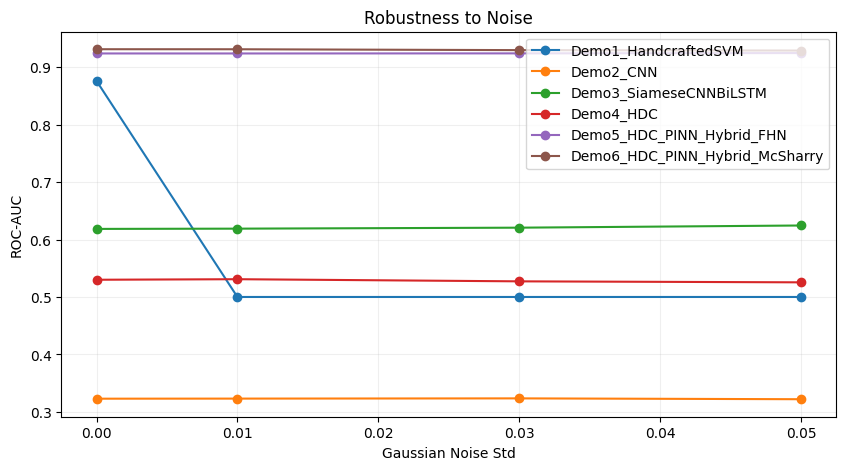

In [ ]:
# Plot robustness by noise
plt.figure(figsize=(10, 5))
for model_name, g in robust_df.groupby("Model"):
    plt.plot(g["NoiseStd"], g["ROC_AUC"], marker="o", label=model_name)
plt.xlabel("Gaussian Noise Std")
plt.ylabel("ROC-AUC")
plt.title("Robustness to Noise")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

## Short-window real-time tests

This section is very important for your **real-time ECG verification** angle.

Try 1s, 2s, 5s windows and compare accuracy vs latency.

In [ ]:
# 16. Window length study
# This supplementary short-window experiment now uses the same subject-independent
# splitting logic as the main benchmark.

def rebuild_for_segment_seconds(new_seconds):
    temp_cfg = CFG(**asdict(cfg))
    temp_cfg.segment_seconds = new_seconds

    seg_df = build_segment_dataframe(temp_cfg)

    if len(seg_df) == 0 or seg_df["subject_id"].nunique() < 3:
        return None, None, None, None

    try:
        _, tr, va, te, _ = build_subject_independent_pair_splits(
            segments_df=seg_df,
            cfg=temp_cfg,
            positive_pairs_per_subject=min(20, temp_cfg.positive_pairs_per_subject),
            negative_pairs_per_subject=min(20, temp_cfg.negative_pairs_per_subject),
            train_frac=0.70,
            val_frac_of_remaining=0.50,
            seed=SEED,
            verbose=False
        )
    except Exception as e:
        print(f"Short-window split failed for {new_seconds}s: {type(e).__name__}: {e}")
        return None, None, None, None

    if len(tr) < 100 or len(va) < 50 or len(te) < 50:
        return None, None, None, None

    return temp_cfg, tr, va, te


# WARNING:
# This can take time. Start with [1.0, 2.0] and expand later.
segment_seconds_list = [1.0, 2.0]

window_rows = []
for seg_sec in segment_seconds_list:
    out = rebuild_for_segment_seconds(seg_sec)
    if out[0] is None:
        continue

    tcfg, tr_df, va_df, te_df = out

    tr_loader = DataLoader(PairDataset(tr_df), batch_size=cfg.batch_size, shuffle=True)
    va_loader = DataLoader(PairDataset(va_df), batch_size=cfg.batch_size, shuffle=False)
    te_loader = DataLoader(PairDataset(te_df), batch_size=cfg.batch_size, shuffle=False)

    model = SimpleVerifier(emb_dim=cfg.embedding_dim)
    model, _ = train_pair_model(
        model,
        tr_loader,
        va_loader,
        epochs=3,
        lr=cfg.lr,
        weight_decay=cfg.weight_decay
    )

    y_win, s_win = eval_pair_model(model, te_loader)
    met = compute_metrics(y_win, s_win)

    bx1, bx2, _ = next(iter(te_loader))
    timing = benchmark_torch_model(
        model,
        (bx1, bx2),
        device=DEVICE,
        warmup=10,
        trials=50
    )

    window_rows.append({
        "SegmentSeconds": seg_sec,
        "SplitProtocol": "subject_independent",
        **met,
        **timing
    })

window_df = pd.DataFrame(window_rows)
window_df



Metadata sample:
  subject_id      record_name  record_index
0  person_01  Person_01/rec_1             1
1  person_01  Person_01/rec_2             2
2  person_01  Person_01/rec_3             3
3  person_01  Person_01/rec_4             4
4  person_02  Person_02/rec_1             1


Loading ecg_id:   0%|          | 0/360 [00:00<?, ?it/s]

FAILED: Person_04/rec_3 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_04/rec_3.hea
FAILED: Person_04/rec_4 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_04/rec_4.hea
FAILED: Person_05/rec_3 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_05/rec_3.hea
FAILED: Person_05/rec_4 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_05/rec_4.hea
FAILED: Person_06/rec_3 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_06/rec_3.hea
FAILED: Person_06/rec_4 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_06/rec_4.hea
FAILED: Person_07/rec_3 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_07/rec_3.hea
FAILED: Perso

Loading ecg_id:   0%|          | 0/360 [00:00<?, ?it/s]

FAILED: Person_04/rec_3 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_04/rec_3.hea
FAILED: Person_04/rec_4 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_04/rec_4.hea
FAILED: Person_05/rec_3 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_05/rec_3.hea
FAILED: Person_05/rec_4 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_05/rec_4.hea
FAILED: Person_06/rec_3 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_06/rec_3.hea
FAILED: Person_06/rec_4 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_06/rec_4.hea
FAILED: Person_07/rec_3 -> NetFileNotFoundError: 404 Error: Not Found for url: https://physionet.org/files/ecgiddb/1.0.0/Person_07/rec_3.hea
FAILED: Perso

,SegmentSeconds,SplitProtocol,ROC_AUC,EER,Threshold,Accuracy,FAR,FRR,TP,TN,FP,FN,avg_batch_sec,avg_pair_sec,pairs_per_sec,theoretical_total_auth_sec
0,1.0,subject_independent,0.366977,0.580357,0.526696,0.419643,0.582143,0.578571,118,117,163,162,0.000345,0.000005,185482.504624,2.000005
1,2.0,subject_independent,0.303603,0.635714,0.520663,0.364286,0.635714,0.635714,102,102,178,178,0.000340,0.000005,188152.495951,2.000005


## External validation on PTB Diagnostic



It answers:
- does the method generalize?
- what happens on a second dataset?

In [ ]:

# 17. Cross-dataset scaffold (PTB self-contained, no earlier code changes)

# Extenal Validation.

import pandas as pd
import wfdb

ptb_cfg = CFG(**asdict(cfg))
ptb_cfg.dataset_name = "ptb"
ptb_cfg.max_subjects = 50          # start small first
ptb_cfg.max_records_per_subject = 4

def build_ptb_metadata_from_records(max_subjects=10, max_records_per_subject=4):
    records = pd.read_csv(
        "https://physionet.org/files/ptbdb/1.0.0/RECORDS",
        header=None,
        names=["record_name"]
    )

    records = records[records["record_name"].str.startswith("patient")].copy()
    records["subject_id"] = records["record_name"].str.split("/").str[0]

    keep_subjects = sorted(records["subject_id"].unique())[:max_subjects]
    records = records[records["subject_id"].isin(keep_subjects)].copy()

    records["record_index"] = records.groupby("subject_id").cumcount() + 1
    records = records[records["record_index"] <= max_records_per_subject].reset_index(drop=True)

    return records[["subject_id", "record_name", "record_index"]]

def safe_read_record_ptb_only(record_name):
    try:
        # record_name looks like: patient001/s0010_re
        patient_dir, rec_base = record_name.split("/")
        rec = wfdb.rdrecord(rec_base, pn_dir=f"ptbdb/{patient_dir}")
        fs = rec.fs
        sig = rec.p_signal[:, 0]   # use lead 0 for consistency
        return sig.astype(np.float32), int(fs)
    except Exception as e:
        print(f"FAILED: {record_name} -> {type(e).__name__}: {e}")
        return None, None

def build_ptb_segment_dataframe_only(ptb_cfg):
    meta = build_ptb_metadata_from_records(
        max_subjects=ptb_cfg.max_subjects,
        max_records_per_subject=ptb_cfg.max_records_per_subject
    )

    print("Metadata sample:")
    display(meta.head())

    segment_rows = []
    loaded_records = 0
    failed_records = 0
    zero_segment_records = 0

    for row in tqdm(meta.itertuples(index=False), total=len(meta), desc="Loading PTB"):
        sig, fs = safe_read_record_ptb_only(row.record_name)

        if sig is None:
            failed_records += 1
            continue

        x = preprocess_record(sig, fs, ptb_cfg)
        segs = segment_signal(
            x,
            fs=ptb_cfg.target_fs,
            segment_seconds=ptb_cfg.segment_seconds,
            step_seconds=max(ptb_cfg.segment_seconds / 2, 0.5),
        )

        if len(segs) == 0:
            zero_segment_records += 1
            continue

        loaded_records += 1

        for k, seg in enumerate(segs):
            if ptb_cfg.normalize_per_segment:
                seg = zscore(seg)

            segment_rows.append({
                "subject_id": row.subject_id,
                "record_name": row.record_name,
                "segment_id": f"{row.record_name}__seg{k}",
                "signal": seg.astype(np.float32),
            })

    out = pd.DataFrame(
        segment_rows,
        columns=["subject_id", "record_name", "segment_id", "signal"]
    )

    print(f"Metadata rows: {len(meta)}")
    print(f"Loaded records: {loaded_records}")
    print(f"Failed records: {failed_records}")
    print(f"Zero-segment records: {zero_segment_records}")
    print(f"Total segments: {len(out)}")

    return out

# Build PTB segments using the local PTB-only loader
ptb_segments_df = build_ptb_segment_dataframe_only(ptb_cfg)

if ptb_segments_df.empty:
    raise RuntimeError("PTB loading still returned 0 segments.")

ptb_pairs_df, ptb_train, ptb_val, ptb_test, ptb_subject_split_info = build_subject_independent_pair_splits(
    segments_df=ptb_segments_df,
    cfg=ptb_cfg,
    positive_pairs_per_subject=20,
    negative_pairs_per_subject=20,
    train_frac=0.70,
    val_frac_of_remaining=0.50,
    seed=SEED,
    verbose=True
)

if ptb_pairs_df.empty:
    raise RuntimeError("PTB subject-independent pair generation returned 0 pairs.")

ptb_test_loader = DataLoader(
    PairDataset(ptb_test),
    batch_size=cfg.batch_size,
    shuffle=False
)



Metadata sample:


,subject_id,record_name,record_index
0,patient001,patient001/s0010_re,1
1,patient001,patient001/s0014lre,2
2,patient001,patient001/s0016lre,3
3,patient002,patient002/s0015lre,1
4,patient003,patient003/s0017lre,1


Loading PTB:   0%|          | 0/161 [00:00<?, ?it/s]

Metadata rows: 161
Loaded records: 161
Failed records: 0
Zero-segment records: 0
Total segments: 18064
Subject-independent split completed
------------------------------------------------------------
Random seed: 42
Total subjects: 50
Train / Validation / Test subjects: 35 7 8
Train / Validation / Test pairs: 1400 280 320
Class balance: 0.5 0.5 0.5

Subject split table


,Split,Subjects,Segments,Pairs,PositiveFraction
0,Train,35,12789,1400,0.5
1,Validation,7,2280,280,0.5
2,Test,8,2995,320,0.5



Pair split diagnostics


,Split,Pairs,PositivePairs,NegativePairs,PositiveFraction,UniqueSubjectsInPairs
0,Train,1400,700,700,0.5,35
1,Validation,280,140,140,0.5,7
2,Test,320,160,160,0.5,8



Subject-overlap diagnostics


,Comparison,OverlapSubjects
0,Train-Val,0
1,Train-Test,0
2,Val-Test,0


Verified: no subject overlap across train/validation/test.


In [ ]:

# Evaluate already-trained ECG-ID models directly on PTB test pairs
y_ptb_2, s_ptb_2 = eval_pair_model(demo2_model, ptb_test_loader)
y_ptb_3, s_ptb_3 = eval_pair_model(demo3_model, ptb_test_loader)
y_ptb_4, s_ptb_4 = eval_pair_model(demo4_model, ptb_test_loader)
y_ptb_5, s_ptb_5 = eval_pair_model(demo5_model, ptb_test_loader)
y_ptb_6, s_ptb_6 = eval_pair_model(demo6_model, ptb_test_loader)


ptb_results_df = pd.DataFrame([
    {"Model": "SimpleVerifier", **compute_metrics(y_ptb_2, s_ptb_2)},
    {"Model": "Siamese", **compute_metrics(y_ptb_3, s_ptb_3)},
    {"Model": "ProposedPINN", **compute_metrics(y_ptb_4, s_ptb_4)},
    {"Model": "HybridHDCPINNVerifierFHN", **compute_metrics(y_ptb_5, s_ptb_5)},
    {"Model": "HybridHDCPINNVerifierFHN_2", **compute_metrics(y_ptb_6, s_ptb_6)},
])

display(ptb_results_df)


,Model,ROC_AUC,EER,Threshold,Accuracy,FAR,FRR,TP,TN,FP,FN
0,SimpleVerifier,0.391094,0.568750,0.501769,0.431250,0.56875,0.56875,69,69,91,91
1,Siamese,0.498945,0.512500,0.562643,0.487500,0.51250,0.51250,78,78,82,82
2,ProposedPINN,0.938672,0.150000,0.386736,0.850000,0.15000,0.15000,136,136,24,24
3,HybridHDCPINNVerifierFHN,0.906523,0.203125,0.561665,0.796875,0.20000,0.20625,127,128,32,33
4,HybridHDCPINNVerifierFHN_2,0.900625,0.187500,0.559379,0.812500,0.20625,0.16875,133,127,33,27


In [ ]:

# Summary Table
results_rows = [
    {"Model": "Demo1_HandcraftedSVM", **demo1_test},
    {"Model": "Demo2_CNN", **demo2_test},
    {"Model": "Demo3_SiameseCNNBiLSTM", **demo3_test},
    {"Model": "Demo4_HDC_NaiveFullPair", **demo4_test},
    {"Model": "Demo4B_HDC_VectorizedFullPair", **demo4_vec_test},
    {"Model": "Demo4C_HDC_TemplatePrecomputed", **demo4_template_test},
    {"Model": "Demo5_HDC_PINN_Hybrid_FHN", **demo5_test},
    {"Model": "Demo6_HDC_PINN_Hybrid_McSharry", **demo6_test},
]

# Include McSharry ablation variants in the performance summary if that cell was run.
if "mcsharry_no_phys_test" in globals():
    results_rows.append({"Model": "Demo6B_HDC_PINN_McSharry_NoPhysics", **mcsharry_no_phys_test})
if "mcsharry_no_hdc_test" in globals():
    results_rows.append({"Model": "Demo6C_HDC_PINN_McSharry_NoHDC", **mcsharry_no_hdc_test})

results_df = pd.DataFrame(results_rows)

print("Performance summary")
display(results_df.sort_values("ROC_AUC", ascending=False))

print("Timing summary")
display(timing_df.sort_values("avg_pair_sec"))

if "hdc_fair_timing_df" in globals():
    print("Fair HDC timing summary")
    display(hdc_fair_timing_df.sort_values("avg_pair_sec"))

if "hdc_fair_results_df" in globals():
    print("Fair HDC deployment-performance summary")
    display(hdc_fair_results_df.sort_values("ROC_AUC", ascending=False))

if "ablation_df" in globals():
    print("Ablation summary")
    display(ablation_df.sort_values("ROC_AUC", ascending=False))


if "mcsharry_ablation_df" in globals():
    print("McSharry-family ablation summary")
    display(mcsharry_ablation_df.sort_values("ROC_AUC", ascending=False))


Performance summary


,Model,ROC_AUC,EER,Threshold,Accuracy,FAR,FRR,TP,TN,FP,FN,missing_claim_templates
8,Demo6B_HDC_PINN_McSharry_NoPhysics,0.959621,0.088393,0.613486,0.911607,0.089286,0.087500,511,510,50,49,NaN
7,Demo6_HDC_PINN_Hybrid_McSharry,0.931154,0.133929,0.518749,0.866071,0.133929,0.133929,485,485,75,75,NaN
9,Demo6C_HDC_PINN_McSharry_NoHDC,0.927331,0.127679,0.545275,0.872321,0.125000,0.130357,487,490,70,73,NaN
6,Demo5_HDC_PINN_Hybrid_FHN,0.923788,0.157143,0.596844,0.842857,0.157143,0.157143,472,472,88,88,NaN
0,Demo1_HandcraftedSVM,0.876084,0.202679,0.587052,0.799107,0.203571,0.198214,449,446,114,111,NaN
2,Demo3_SiameseCNNBiLSTM,0.618444,0.413393,0.529955,0.586607,0.412500,0.414286,328,329,231,232,NaN
5,Demo4C_HDC_TemplatePrecomputed,0.578516,0.459821,0.443000,0.540179,0.457143,0.462500,301,304,256,259,0.0
4,Demo4B_HDC_VectorizedFullPair,0.529970,0.489286,0.435000,0.516964,0.332143,0.633929,205,374,186,355,NaN
3,Demo4_HDC_NaiveFullPair,0.529970,0.489286,0.435000,0.516964,0.332143,0.633929,205,374,186,355,NaN
1,Demo2_CNN,0.322986,0.624107,0.501769,0.375893,0.623214,0.625000,210,211,349,350,NaN


Timing summary


,Model,Params,avg_batch_sec,avg_pair_sec,pairs_per_sec,theoretical_total_auth_sec
0,Demo2_CNN,17410.0,0.000339,0.000005,188690.031544,2.000005
1,Demo3_SiameseCNNBiLSTM,40289.0,0.000407,0.000006,157249.776109,2.000006
2,Demo6_HDC_PINN_Hybrid_McSharry,107862.0,0.000637,0.000010,100475.733760,2.000010
3,Demo6B_HDC_PINN_McSharry_NoPhysics,107862.0,0.000638,0.000010,100351.493650,2.000010
4,Demo6C_HDC_PINN_McSharry_NoHDC,107862.0,0.000639,0.000010,100183.896935,2.000010
5,Demo5_HDC_PINN_Hybrid_FHN,180682.0,0.000679,0.000011,94268.501615,2.000011
7,Demo1_HandcraftedSVM,NaN,0.004999,0.000078,12801.510578,2.000078
6,Demo4_HDC_NaiveFullPair,2000.0,0.285123,0.002851,350.725361,2.002851


Fair HDC timing summary


...

,Model,Evaluation,ROC_AUC,EER,Threshold,Accuracy,FAR,FRR,TP,TN,FP,FN,missing_claim_templates
2,Demo4C_HDC_TemplatePrecomputed,claimed-identity template auth,0.578516,0.459821,0.443,0.540179,0.457143,0.462500,301,304,256,259,0.0
0,Demo4_HDC_NaiveFullPair,pairwise,0.529970,0.489286,0.435,0.516964,0.332143,0.633929,205,374,186,355,NaN
1,Demo4B_HDC_VectorizedFullPair,pairwise,0.529970,0.489286,0.435,0.516964,0.332143,0.633929,205,374,186,355,NaN


Ablation summary


,Variant,Uses_HDC,Uses_Physics,Uses_Recon,Uses_Morph,Uses_Smooth,Params,ROC_AUC,EER,Threshold,Accuracy,FAR,FRR,TP,TN,FP,FN
1,A1_Hybrid_no_physics,True,False,True,True,True,180682,0.968670,0.085714,0.607151,0.914286,0.085714,0.085714,512,512,48,48
0,A0_PINN_only,False,False,True,True,True,107797,0.967596,0.083036,0.263617,0.916964,0.083929,0.082143,514,513,47,46
3,A3_Full_HDC_PINN_hybrid,True,True,True,True,True,180682,0.923788,0.157143,0.596844,0.842857,0.157143,0.157143,472,472,88,88
2,A2_Hybrid_no_HDC_loss,True,True,True,True,True,180682,0.923603,0.165179,0.617154,0.834821,0.166071,0.164286,468,467,93,92


McSharry-family ablation summary


,Variant,Uses_HDC,Uses_Physics,Uses_Recon,Uses_Morph,Uses_Smooth,Params,ROC_AUC,EER,Threshold,Accuracy,FAR,FRR,TP,TN,FP,FN
0,M0_PINN_only,False,False,True,True,True,107797,0.967596,0.083036,0.263617,0.916964,0.083929,0.082143,514,513,47,46
1,M1_McSharry_no_physics,True,False,True,True,True,107862,0.959621,0.088393,0.613486,0.911607,0.089286,0.087500,511,510,50,49
3,M3_Full_McSharry_hybrid,True,True,True,True,True,107862,0.931154,0.133929,0.518749,0.866071,0.133929,0.133929,485,485,75,75
2,M2_McSharry_no_HDC_loss,True,True,True,True,True,107862,0.927331,0.127679,0.545275,0.872321,0.125000,0.130357,487,490,70,73


In [ ]:
# =========================
# Save trained models and demo artifacts
# =========================
import json
import joblib

ARTIFACT_DIR = "ecg_demo_saved_models"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# -------------------------
# Save config
# -------------------------
config_to_save = asdict(cfg)
config_to_save["SEED"] = SEED
config_to_save["DEVICE_USED_FOR_TRAINING"] = DEVICE

with open(os.path.join(ARTIFACT_DIR, "config.json"), "w") as f:
    json.dump(config_to_save, f, indent=2)


# -------------------------
# Save sklearn SVM baseline
# -------------------------
if "svm_clf" in globals():
    joblib.dump(svm_clf, os.path.join(ARTIFACT_DIR, "demo1_handcrafted_svm.joblib"))


# -------------------------
# Helper for PyTorch models
# -------------------------
def save_torch_model(model, filename, model_name, extra_info=None):
    if model is None:
        print(f"Skipping {model_name}: model is None")
        return

    payload = {
        "model_name": model_name,
        "state_dict": model.cpu().state_dict(),
        "config": config_to_save,
        "extra_info": extra_info or {},
    }

    torch.save(payload, os.path.join(ARTIFACT_DIR, filename))
    model.to(DEVICE)
    print(f"Saved {model_name} -> {filename}")


# -------------------------
# Save PyTorch models
# -------------------------
if "demo2_model" in globals():
    save_torch_model(
        demo2_model,
        "demo2_cnn.pt",
        "SimpleVerifier_CNN",
        {"metrics": demo2_test if "demo2_test" in globals() else None}
    )

if "demo3_model" in globals():
    save_torch_model(
        demo3_model,
        "demo3_siamese_cnn_bilstm.pt",
        "SiameseCNNBiLSTM",
        {"metrics": demo3_test if "demo3_test" in globals() else None}
    )

if "demo4_pinn_model" in globals():
    save_torch_model(
        demo4_pinn_model,
        "demo4_pinn_only.pt",
        "ProposedPINNVerifier",
        {"metrics": demo4_pinn_test if "demo4_pinn_test" in globals() else None}
    )

if "demo5_model" in globals():
    save_torch_model(
        demo5_model,
        "demo5_hdc_pinn_fhn.pt",
        "HybridHDCPINNVerifierFHN",
        {"metrics": demo5_test if "demo5_test" in globals() else None}
    )

if "demo6_model" in globals():
    save_torch_model(
        demo6_model,
        "demo6_full_mcsharry.pt",
        "HybridHDCPINNVerifierMcSharry",
        {"metrics": demo6_test if "demo6_test" in globals() else None}
    )

if "mcsharry_no_phys" in globals():
    save_torch_model(
        mcsharry_no_phys,
        "demo6b_mcsharry_no_physics.pt",
        "HybridHDCPINNVerifierMcSharry_NoPhysics",
        {"metrics": mcsharry_no_phys_test if "mcsharry_no_phys_test" in globals() else None}
    )

if "mcsharry_no_hdc_loss" in globals():
    save_torch_model(
        mcsharry_no_hdc_loss,
        "demo6c_mcsharry_no_hdc_loss.pt",
        "HybridHDCPINNVerifierMcSharry_NoHDCLoss",
        {"metrics": mcsharry_no_hdc_test if "mcsharry_no_hdc_test" in globals() else None}
    )


# -------------------------
# Save HDC encoders if available
# -------------------------
if "hdc_encoder" in globals():
    joblib.dump(hdc_encoder, os.path.join(ARTIFACT_DIR, "demo4_hdc_encoder_naive.joblib"))

if "hdc_encoder_vec" in globals():
    joblib.dump(hdc_encoder_vec, os.path.join(ARTIFACT_DIR, "demo4b_hdc_encoder_vectorized.joblib"))

if "hdc_templates" in globals():
    joblib.dump(hdc_templates, os.path.join(ARTIFACT_DIR, "demo4c_hdc_templates.joblib"))


# -------------------------
# Save result tables
# -------------------------
tables_to_save = {
    "main_results.csv": "results_df",
    "timing_results.csv": "timing_df",
    "fhn_ablation_results.csv": "ablation_df",
    "mcsharry_ablation_results.csv": "mcsharry_ablation_df",
    "hdc_fair_timing.csv": "hdc_fair_timing_df",
    "hdc_fair_results.csv": "hdc_fair_results_df",
    "robustness_results.csv": "robust_df",
    "short_window_results.csv": "window_df",
    "ptb_results.csv": "ptb_results_df",
    "subject_split_table.csv": "subject_split_table",
}

for filename, varname in tables_to_save.items():
    if varname in globals():
        obj = globals()[varname]
        if isinstance(obj, pd.DataFrame):
            obj.to_csv(os.path.join(ARTIFACT_DIR, filename), index=False)
            print(f"Saved table -> {filename}")


# -------------------------
# Save thresholds in one JSON
# -------------------------
thresholds = {}

metric_vars = [
    "demo1_test",
    "demo2_test",
    "demo3_test",
    "demo4_pinn_test",
    "demo4_test",
    "demo5_test",
    "demo6_test",
    "mcsharry_no_phys_test",
    "mcsharry_no_hdc_test",
]

for var in metric_vars:
    if var in globals() and isinstance(globals()[var], dict):
        metrics = globals()[var]
        thresholds[var] = {
            "Threshold": metrics.get("Threshold", None),
            "ROC_AUC": metrics.get("ROC_AUC", None),
            "EER": metrics.get("EER", None),
            "Accuracy": metrics.get("Accuracy", None),
            "FAR": metrics.get("FAR", None),
            "FRR": metrics.get("FRR", None),
        }

with open(os.path.join(ARTIFACT_DIR, "thresholds_and_metrics.json"), "w") as f:
    json.dump(thresholds, f, indent=2)

print("\nSaved artifacts to:", ARTIFACT_DIR)
print("Files:")
print(os.listdir(ARTIFACT_DIR))

Saved SimpleVerifier_CNN -> demo2_cnn.pt
Saved SiameseCNNBiLSTM -> demo3_siamese_cnn_bilstm.pt
Saved ProposedPINNVerifier -> demo4_pinn_only.pt
Saved HybridHDCPINNVerifierFHN -> demo5_hdc_pinn_fhn.pt
Saved HybridHDCPINNVerifierMcSharry -> demo6_full_mcsharry.pt
Saved HybridHDCPINNVerifierMcSharry_NoPhysics -> demo6b_mcsharry_no_physics.pt
Saved HybridHDCPINNVerifierMcSharry_NoHDCLoss -> demo6c_mcsharry_no_hdc_loss.pt
Saved table -> main_results.csv
Saved table -> timing_results.csv
Saved table -> fhn_ablation_results.csv
Saved table -> mcsharry_ablation_results.csv
Saved table -> hdc_fair_timing.csv
Saved table -> hdc_fair_results.csv
Saved table -> robustness_results.csv
Saved table -> short_window_results.csv
Saved table -> ptb_results.csv

Saved artifacts to: ecg_demo_saved_models
Files:
['demo6c_mcsharry_no_hdc_loss.pt', 'main_results.csv', 'demo1_handcrafted_svm.joblib', 'demo6_full_mcsharry.pt', 'demo4c_hdc_templates.joblib', 'hdc_fair_results.csv', 'demo4b_hdc_encoder_vectorized

In [ ]:
# =========================
# Zip artifacts for Gradio/demo deployment
# =========================

!zip -r ecg_demo_saved_models.zip ecg_demo_saved_models
from google.colab import files
files.download("ecg_demo_saved_models.zip")

updating: ecg_demo_saved_models/ (stored 0%)
updating: ecg_demo_saved_models/demo6c_mcsharry_no_hdc_loss.pt (deflated 7%)
updating: ecg_demo_saved_models/main_results.csv (deflated 56%)
updating: ecg_demo_saved_models/demo1_handcrafted_svm.joblib (deflated 48%)
updating: ecg_demo_saved_models/demo6_full_mcsharry.pt (deflated 7%)
updating: ecg_demo_saved_models/demo4c_hdc_templates.joblib (deflated 94%)
updating: ecg_demo_saved_models/hdc_fair_results.csv (deflated 51%)
updating: ecg_demo_saved_models/demo4b_hdc_encoder_vectorized.joblib (deflated 75%)
updating: ecg_demo_saved_models/demo4_hdc_encoder_naive.joblib (deflated 75%)
updating: ecg_demo_saved_models/timing_results.csv (deflated 49%)
updating: ecg_demo_saved_models/demo6b_mcsharry_no_physics.pt (deflated 7%)
updating: ecg_demo_saved_models/demo2_cnn.pt (deflated 13%)
updating: ecg_demo_saved_models/thresholds_and_metrics.json (deflated 72%)
updating: ecg_demo_saved_models/robustness_results.csv (deflated 67%)
updating: ecg_dem

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Future Work:


Deployement: